# Curso de Machine Learning 2026
# Parte 2A — Preparación y evaluación

Segunda parte del curso, primera de sus dos mitades. Acá se prepara el dataset para modelar y se
construye el criterio con el que después se va a juzgar a los modelos:

*  División del dataset
*  Fuga de información
*  Sobreajuste
*  Validación cruzada


Los cuatro algoritmos y la comparativa están en la **Parte 2B**, que arranca en el punto 7.

**Qué necesita para arrancar**

El archivo `dataset_limpio.csv` que produjo la **Parte 1**. No hace falta tenerlo descargado:
por defecto el cuaderno lo lee directamente del repositorio de GitHub del proyecto, así que se abre
y se ejecuta. El punto 0.2 explica las dos alternativas.

**Qué hace este cuaderno**

1. Carga el dataset limpio y verifica que sea lo que espera.
2. Lo transforma: codifica la etiqueta y muestra el escalado.
3. Divide en entrenamiento y prueba, y demuestra por qué una sola división no alcanza.
4. Explica y demuestra dos problemas que arruinan cualquier evaluación: la **fuga de información**
   y el **sobreajuste**.
5. Llega a la validación cruzada, que es la forma de medir que usa toda la Parte 2B.
6. Exporta el estado para que la Parte 2B siga desde ahí.

**Por qué son dos cuadernos**

Por uan cuestion de simplicidad y conceptualmente son dos cosas distintas:

*  Parte 2A **define cómo se mide**
*  Parte 2B **mide usando distintos modelos**


El corte cae en una junta natural:
el punto 6 termina fijando el esquema de validación, y el 7 empieza a usarlo.

La numeración **no se reinicia**: la Parte 2B arranca en el punto 7. El texto de los dos cuadernos
está lleno de referencias cruzadas —"la forma 2 del punto 5.4", "la fuga del punto 4.3"—, y
renumerar las rompería todas.

**Las librerías se importan por bloques**, justo antes de la sección que las usa, en lugar de todas
juntas al principio. Así se ve qué necesita cada etapa, y cada cuaderno carga solamente lo que usa.

---

# Índice — Parte 2A

### Parte 0 — Preliminares
- [0.1 Qué necesita este cuaderno](#sec-0-1)
- [0.2 Cargar el dataset limpio](#sec-0-2)
- [0.3 Verificación de entrada](#sec-0-3)
- [0.4 Configuración global](#sec-0-4)
- [0.5 Librerías de gráficos y estilo](#sec-0-5)

### 1. ¿Qué es Machine Learning? Dónde estamos parados
- [1.1 Aprendizaje supervisado y no supervisado](#sec-1-1)
- [1.2 Regresión y clasificación: dos preguntas distintas](#sec-1-2)
- [1.3 Diagnóstico de nuestro problema](#sec-1-3)
- [1.4 Los cuatro modelos que vamos a usar](#sec-1-4)

### 2. Transformación de datos
- [2.1 Feature engineering](#sec-2-1)
- [2.2 Codificación de la variable categórica](#sec-2-2)
- [2.3 Normalización y estandarización](#sec-2-3)
- [2.4 Las matrices X e y](#sec-2-4)

### 3. División del dataset: entrenamiento y prueba
- [3.1 Por qué hay que dividir](#sec-3-1)
- [3.2 La división 80/20 estratificada](#sec-3-2)
- [3.3 La fragilidad de una sola división](#sec-3-3)

### 4. Fuga de información (data leakage)
- [4.1 Qué es](#sec-4-1)
- [4.2 Por qué es tan grave: el síntoma es que no hay síntoma](#sec-4-2)
- [4.3 Las siete formas en que se cuela](#sec-4-3)
- [4.4 Demostración 1 — el escalador que mira de más](#sec-4-4)
- [4.5 Demostración 2 — "predecir" ruido puro muy por encima del azar](#sec-4-5)
- [4.6 El Pipeline como antídoto](#sec-4-6)
- [4.7 Lista de control](#sec-4-7)

### 5. Overfitting y underfitting
- [5.1 Qué es cada uno](#sec-5-1)
- [5.2 El compromiso sesgo-varianza](#sec-5-2)
- [5.3 Las señales: tabla de diagnóstico](#sec-5-3)
- [5.4 Las cuatro formas de detectarlo](#sec-5-4)
- [5.5 Cómo se mide: la brecha y sus umbrales](#sec-5-5)
- [5.6 Qué hacer con cada uno](#sec-5-6)
- [5.7 En código: tres niveles de complejidad](#sec-5-7)
- [5.8 La curva de validación](#sec-5-8)
- [5.9 La curva de aprendizaje](#sec-5-9)

### 6. Validación cruzada K-Fold
- [6.1 Cómo funciona](#sec-6-1)
- [6.2 Cuántos pliegues, y por qué acá no es opcional](#sec-6-2)
- [6.3 El esquema estratificado](#sec-6-3)
- [6.4 Una división contra validación cruzada](#sec-6-4)

### Exportar el estado para la Parte 2B
- [Los archivos que deja este cuaderno](#sec-export-1)
- [Cómo llevártelos](#sec-export-2)

### Cierre
- [Resumen de lo hecho](#sec-cierre)

**Los modelos** —Regresión Logística, KNN, Árbol de Decisión y Random Forest— y la comparativa
final están en la **Parte 2B**, puntos 7 a 12.

---
# Parte 0 — Preliminares

<a id="sec-0-1"></a>
## 0.1 Qué necesita este cuaderno

**La entrada:** el archivo `dataset_limpio.csv` que dejó la Parte 1. Tiene 171 filas y 8 columnas:
`TAG` con las clases `AFI` y `NEG`, y siete columnas numéricas.

**Qué se le hizo en la Parte 1**

  * Verificado que no hay valores faltantes
  * Verificado que no hay duplicados ni contradicciones
  * Verificado que los tipos son correctos
  * Verificado que los rangos son posibles
  * Detectados los outliers, y conservados a propósito

**Qué vamos a hacer en esta Parte 2A**  

  * Codificar la etiqueta a 0 y 1
  * Escalar las variables
  * Dividir en entrenamiento y prueba
  * Entrenar y comparar

Codificar y escalar dependen de qué modelo se vaya a usar, y —como vamos a ver en el punto 4— tienen que aplicarse adentro del pipeline, después de la división, para no arruinar la evaluación.

<a id="sec-0-2"></a>
## 0.2 Cargar el dataset limpio

Dos formas de traer el archivo. La que quede sin comentar tiene que dejar la ruta en la variable
`RUTA_DATOS`.

| Cómo | Cuándo conviene |
|---|---|
| **A** — Desde GitHub | Siempre que haya conexión. Es la que queda **activa**: no hay que descargar ni subir nada |
| **B** — Subir el archivo a mano | Si queremos trabajar con tu propia versión del CSV, o no tenés acceso al repositorio |

**Sobre la opción A.** GitHub tiene dos direcciones para cada archivo: la de la página web, que
devuelve el archivo *mostrado dentro del sitio* —es decir, HTML—, y la de `raw.githubusercontent.com`,
que devuelve el contenido crudo. Pandas necesita la segunda. La celda la arma sola a partir del
usuario, el repositorio y la rama, así que para apuntar a otro repositorio alcanza con cambiar esas
tres variables. El repositorio tiene que ser público.

**Sobre la opción B.** `files.upload()` abre un diálogo del navegador para elegir el archivo desde
tu máquina. Solo funciona en Colab, y el archivo vive en la sesión: cuando el entorno se reinicia
hay que volver a subirlo.

In [6]:
NOMBRE_ARCHIVO = "dataset_limpio.csv"

# ---------------------------------------------------------------------
# OPCIÓN A — Desde GitHub   (ACTIVA)
# ---------------------------------------------------------------------
USUARIO = "FerCipriani"            # <-- cambiar si usás otro repositorio
REPO    = "CursoML_Proyecto_IVE"   # <-- cambiar si usás otro repositorio
RAMA    = "main"                   # GitHub usa 'main' por defecto

RUTA_DATOS = f"https://raw.githubusercontent.com/{USUARIO}/{REPO}/{RAMA}/{NOMBRE_ARCHIVO}"

# ---------------------------------------------------------------------
# OPCIÓN B — Subir el archivo a mano   (solo Colab)
# ---------------------------------------------------------------------
# from google.colab import files
# RUTA_DATOS = list(files.upload().keys())[0]

print(f"Ruta configurada: {RUTA_DATOS}")

Ruta configurada: https://raw.githubusercontent.com/FerCipriani/CursoML_Proyecto_IVE/main/dataset_limpio.csv


Ahora las librerías de datos y la lectura.

La celda detecta sola si la ruta termina en `.csv` o en `.xlsx` y usa la función que corresponde,
así que sirve igual si en vez del CSV limpio le pasás un Excel. Y si la lectura falla —típicamente
porque no hay conexión, o porque se cambió el nombre del repositorio— reintenta con un archivo
local del mismo nombre antes de darse por vencida.

In [7]:
# --- Librerías de manipulación de datos ---
import numpy as np
import pandas as pd

print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")
print()


# --- Lectura: elige la función según la extensión ---
def leer_datos(ruta):
    if str(ruta).lower().endswith((".xlsx", ".xls")):
        return pd.read_excel(ruta)
    return pd.read_csv(ruta)


try:
    df = leer_datos(RUTA_DATOS)
except Exception as error:
    print(f"[AVISO] No se pudo leer: {RUTA_DATOS}")
    print(f"        {type(error).__name__}: {str(error)[:110]}")
    print(f"        Reintentando con el archivo local '{NOMBRE_ARCHIVO}'...")
    df = leer_datos(NOMBRE_ARCHIVO)
    RUTA_DATOS = NOMBRE_ARCHIVO

print("=" * 70)
print("  LECTURA")
print("=" * 70)
print(f"  Archivo     : {RUTA_DATOS}")
print(f"  Dimensiones : {df.shape[0]} filas x {df.shape[1]} columnas")
print()
display(df.head())

NumPy  : 2.1.3
Pandas : 2.2.3

  LECTURA
  Archivo     : https://raw.githubusercontent.com/FerCipriani/CursoML_Proyecto_IVE/main/dataset_limpio.csv
  Dimensiones : 171 filas x 8 columnas



,TAG,T0,T1,T2,T3,T4,T5,T6
0,AFI,0.022825,0.207035,0.381847,0.274705,0.000269,0.113050,0.000269
1,AFI,0.006774,0.003968,0.049423,0.176527,0.031185,0.442240,0.289883
2,AFI,0.127329,0.000518,0.199793,0.333851,0.025880,0.015010,0.297619
3,AFI,0.208518,0.127773,0.090506,0.202307,0.143301,0.000444,0.227152
4,AFI,0.000429,0.393822,0.192621,0.270699,0.000429,0.000429,0.141570


<a id="sec-0-3"></a>
## 0.3 Verificación de entrada

La Parte 1 dejó el dataset auditado, pero este cuaderno **no da eso por sentado**. Repite los
controles esenciales antes de tocar nada.

No es desconfianza gratuita: en un pipeline real, la etapa que consume un archivo no sabe quién lo
generó ni si se modificó en el camino. Alguien pudo haber abierto el CSV en Excel y guardado con
otro separador decimal; pudo haberse subido una versión vieja; pudo haberse leído la hoja
equivocada. Verificar la entrada cuesta una celda y evita horas de confusión.

Los cinco controles:

*  Nulos
*  Duplicados
*  Tipos
*  Rangos
*  Que la etiqueta tenga exactamente dos clases

In [8]:
print("=" * 78)
print("  VERIFICACIÓN DE ENTRADA")
print("=" * 78)

COLUMNA_OBJETIVO = "TAG"
objetivo = COLUMNA_OBJETIVO

problemas = []

# 1. ¿Está la columna objetivo?
if objetivo not in df.columns:
    problemas.append(f"no existe la columna objetivo '{objetivo}'")
    print(f"  [ERROR] No está la columna '{objetivo}'. Columnas: {list(df.columns)}")
else:
    print(f"  [OK] Columna objetivo '{objetivo}' presente")

# 2. Predictoras numéricas
predictoras = [c for c in df.columns
               if c != objetivo and pd.api.types.is_numeric_dtype(df[c])]
no_numericas = [c for c in df.columns if c != objetivo and c not in predictoras]
print(f"  [OK] Variables predictoras numéricas: {len(predictoras)}")
if no_numericas:
    problemas.append(f"columnas no numéricas fuera del objetivo: {no_numericas}")
    print(f"  [AVISO] Columnas no numéricas que quedan fuera: {no_numericas}")

# 3. Nulos
nulos = int(df.isna().sum().sum())
if nulos:
    problemas.append(f"{nulos} valores faltantes")
    print(f"  [ERROR] Hay {nulos} valores faltantes. Volvé a la Parte 1.")
else:
    print("  [OK] Sin valores faltantes")

# 4. Duplicados
duplicados = int(df.duplicated().sum())
if duplicados:
    problemas.append(f"{duplicados} filas duplicadas")
    print(f"  [AVISO] Hay {duplicados} filas duplicadas.")
else:
    print("  [OK] Sin filas duplicadas")

# 5. Clases
clases = sorted(df[objetivo].astype(str).unique())
if len(clases) != 2:
    problemas.append(f"la etiqueta tiene {len(clases)} clases, no 2")
    print(f"  [ERROR] La etiqueta tiene {len(clases)} clases: {clases}")
    print("          Este cuaderno está armado para clasificación BINARIA.")
else:
    print(f"  [OK] Clasificación binaria: {clases}")

# 6. Rangos
if predictoras:
    minimo = df[predictoras].to_numpy().min()
    maximo = df[predictoras].to_numpy().max()
    print(f"  [OK] Rango de las predictoras: {minimo:.6f} a {maximo:.6f}")
    sumas = df[predictoras].sum(axis=1)
    if np.allclose(sumas, 1.0, atol=1e-6):
        print("  [OK] Las filas suman 1: las variables son proporciones de un total fijo")

print()
if problemas:
    print(f"  RESULTADO: {len(problemas)} problema(s) -> {problemas}")
    print("  Revisá la Parte 1 antes de seguir.")
else:
    print("  RESULTADO: el dataset pasó todos los controles. Se puede modelar.")

print()
print(f"  Reparto de clases:")
conteo = df[objetivo].value_counts()
proporcion = df[objetivo].value_counts(normalize=True)
for clase in conteo.index:
    print(f"    {clase:>5} : {conteo[clase]:>4} casos ({proporcion[clase]:.1%})")
linea_base = proporcion.max()
clase_mayoritaria = proporcion.idxmax()
print(f"  LÍNEA DE BASE: {linea_base:.2%}  (responder siempre '{clase_mayoritaria}')")

  VERIFICACIÓN DE ENTRADA
  [OK] Columna objetivo 'TAG' presente
  [OK] Variables predictoras numéricas: 7
  [OK] Sin valores faltantes
  [OK] Sin filas duplicadas
  [OK] Clasificación binaria: ['AFI', 'NEG']
  [OK] Rango de las predictoras: 0.000120 a 0.714286
  [OK] Las filas suman 1: las variables son proporciones de un total fijo

  RESULTADO: el dataset pasó todos los controles. Se puede modelar.

  Reparto de clases:
      AFI :   95 casos (55.6%)
      NEG :   76 casos (44.4%)
  LÍNEA DE BASE: 55.56%  (responder siempre 'AFI')


<a id="sec-0-4"></a>
## 0.4 Configuración global

Todos los valores que se podrían querer cambiar, juntos y con nombre propio.

Dos merecen explicación:

- **`SEMILLA`** — varios procedimientos que vamos a usar tienen un componente aleatorio: cómo se
  mezclan las filas antes de partirlas, qué variables mira un árbol en cada nodo, qué muestra le
  toca a cada árbol del bosque. Fijar la semilla hace que esa aleatoriedad sea siempre la misma y
  que el cuaderno dé el mismo resultado cada vez que se corre. Sin semilla fija, los números
  cambian en cada ejecución y no se puede comparar nada.

- **`CLASE_POSITIVA`** — en clasificación binaria hay que decidir cuál de las dos clases es "la
  positiva". Esa elección **no** afecta el accuracy, pero **sí** afecta la precisión, el recall y
  el F1-score, porque esas métricas están definidas desde el punto de vista de la clase positiva.
  La elección es arbitraria; lo que no es arbitrario es dejarla escrita.

In [9]:
# --- Reproducibilidad ---
SEMILLA = 65

# --- El problema ---
CLASE_POSITIVA = "AFI"    # la otra pasa a ser la negativa

# --- Validación cruzada ---
N_PLIEGUES = 10

# --- Umbrales del diagnóstico de ajuste (punto 5) ---
BRECHA_SOBREAJUSTE = 0.10   # (score entrenamiento - score validación) por encima de esto
DESVIO_INESTABLE   = 0.08   # desvío entre pliegues por encima de esto
SCORE_SUBAJUSTE    = 0.70   # score de validación por debajo de esto

# --- Formato de la salida ---
import warnings
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
warnings.filterwarnings("ignore")

clase_negativa = [c for c in clases if c != CLASE_POSITIVA][0]

print("Configuración cargada.")
print(f"  Semilla           : {SEMILLA}")
print(f"  Clase positiva    : {CLASE_POSITIVA}  (la negativa es {clase_negativa})")
print(f"  Pliegues (K-Fold) : {N_PLIEGUES}")
print(f"  Umbral sobreajuste: {BRECHA_SOBREAJUSTE}")
print(f"  Umbral desvío     : {DESVIO_INESTABLE}")
print(f"  Umbral subajuste  : {SCORE_SUBAJUSTE}")

Configuración cargada.
  Semilla           : 65
  Clase positiva    : AFI  (la negativa es NEG)
  Pliegues (K-Fold) : 10
  Umbral sobreajuste: 0.1
  Umbral desvío     : 0.08
  Umbral subajuste  : 0.7


<a id="sec-0-5"></a>
## 0.5 Librerías de gráficos y estilo

Este cuaderno grafica en casi todas sus secciones, así que las librerías de visualización y el
estilo se configuran una vez, acá.

- **Matplotlib** — la base. Controla cada detalle: ejes, colores, leyendas.
- **Seaborn** — construida encima. Menos código para gráficos estadísticos.

Fijamos también un color por clase y uno por modelo, para que los gráficos de todo el cuaderno se
puedan comparar de un vistazo. Que la Regresión Logística sea siempre azul y el Random Forest
siempre violeta no es cosmético: es lo que permite leer la comparativa final sin consultar la
leyenda cada vez.

In [10]:
# --- Librerías de gráficos ---
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# --- Estilo global ---
sns.set_theme(style="whitegrid", palette="deep")
mpl.rcParams["figure.figsize"] = (10, 5)
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["axes.titlesize"] = 12
mpl.rcParams["axes.titleweight"] = "bold"
mpl.rcParams["font.size"] = 10

# --- Colores fijos ---
COLOR_CLASE = {"AFI": "#1f77b4", "NEG": "#d62728"}

print(f"Matplotlib : {mpl.__version__}")
print(f"Seaborn    : {sns.__version__}")
print()
print("Colores por clase:", COLOR_CLASE)

Matplotlib : 3.10.0
Seaborn    : 0.13.2

Colores por clase: {'AFI': '#1f77b4', 'NEG': '#d62728'}


---
# 1. ¿Qué es Machine Learning? Dónde estamos parados

<a id="sec-1-1"></a>
## 1.1 Aprendizaje supervisado y no supervisado

En el enfoque clásico, una persona define las reglas: *si el asunto contiene tal palabra y el remitente está en tal lista, entonces es
spam*.

En Machine Learning el sistema **descubre las reglas solo**, a partir de ejemplos ya resueltos. Y lo que se busca no es que memorice esos ejemplos, sino que **generalice**: que funcione con casos nuevos que nunca vio.


**Los dos tipos principales de aprendizaje**

- **Supervisado.** Los datos vienen con la respuesta conocida (una "etiqueta"). El modelo busca la
  relación entre las variables de entrada y esa etiqueta. Se divide a su vez en **regresión**
  (etiqueta numérica continua) y **clasificación** (etiqueta categórica).
- **No supervisado.** No hay etiqueta. El objetivo es descubrir estructura oculta en los datos. El
  caso típico es el *clustering*: agrupar casos parecidos entre sí.

La diferencia está en si el dataset tiene o no etiquetas que guíen al modelo. El nuestro las tiene:
la columna `TAG`. Es un problema **supervisado**.

**El ciclo de vida de un proyecto**

| Etapa | Dónde está |
|---|---|
| 1. Recolección y comprensión de los datos | Parte 1, puntos 0.2 y 1 |
| 2. Análisis exploratorio (EDA) y limpieza | Parte 1, puntos 2 y 3 |
| 3. Preprocesamiento y preparación | **Parte 2A, punto 2** |
| 4. Selección y entrenamiento del modelo | **Parte 2B, puntos 8 a 11** |
| 5. Evaluación del modelo | **Parte 2A punto 6, Parte 2B punto 12** |
| 6. Implementación y monitoreo | fuera del alcance de estos cuadernos |
| 7. Mantenimiento y mejora continua | fuera del alcance de estos cuadernos |

Entre las dos partes cubrimos las etapas 1 a 5. Las dos últimas empiezan cuando el modelo sale a
producción.

<a id="sec-1-2"></a>
## 1.2 Regresión y clasificación: dos preguntas distintas

Los dos son problemas de aprendizaje supervisado —los dos parten de datos con la respuesta
conocida— pero responden preguntas de naturaleza distinta.

### Regresión: la pregunta es "¿cuánto?"

La variable objetivo es un **número continuo**: un precio, una cantidad de días, una temperatura,
un monto. La salida del modelo puede ser cualquier valor real.

El modelo básico es la **regresión lineal**, que ajusta la recta `y = a·x + b` que mejor pasa entre
los puntos —o su versión con varias variables,
`y = a₁·x₁ + a₂·x₂ + … + aₙ·xₙ + b`—. Se evalúa con métricas que miden *cuán lejos* quedó de la
realidad:

| Métrica | Qué mide | Cuándo conviene |
|---|---|---|
| **MAE** (error absoluto medio) | El promedio de los errores, en las unidades originales | Cuando se quiere una idea clara del margen de error: "se equivoca en promedio por $8.500" |
| **MSE** (error cuadrático medio) | Eleva cada error al cuadrado antes de promediar | Cuando los errores grandes son mucho peores que los chicos. Pierde las unidades originales |
| **RMSE** (raíz del MSE) | La raíz cuadrada del anterior | El punto medio: castiga los errores grandes pero recupera las unidades |
| **R²** (coeficiente de determinación) | Qué proporción de la variabilidad explica el modelo | Para saber cuánto aporta el modelo respecto de responder siempre el promedio |

**Ejemplos de regresión:** predecir el precio de una casa según su superficie y ubicación; estimar
cuántos días va a durar una internación; anticipar el monto de los reclamos de un cliente en un
año; calcular el tiempo de entrega de un envío.

### Clasificación: la pregunta es "¿cuál?"

La variable objetivo es una **categoría**. Cuando hay solo dos categorías posibles se llama
**clasificación binaria**, que es nuestro caso. Con tres o más, **multiclase**.

El modelo básico es la **regresión logística** que —a pesar del nombre— no predice un número sino
la **probabilidad** de pertenecer a una clase: calcula una combinación lineal de las variables y la
pasa por una función **sigmoide**, que aplasta cualquier número real al intervalo entre 0 y 1.
Después se aplica un **umbral de corte**, habitualmente 0,5, para convertir esa probabilidad en una
decisión.

Las métricas son completamente distintas, porque ya no medimos distancias sino aciertos y errores:

| Métrica | Qué mide | Cuándo conviene |
|---|---|---|
| **Accuracy** (precisión general) | Qué proporción del total acertó | Cuando las clases están balanceadas |
| **Recall** (sensibilidad) | De los casos que realmente eran positivos, cuántos detectó | Cuando dejar pasar un positivo es caro: diagnóstico médico, detección de fraude |
| **Precisión** | De los que predije positivos, cuántos lo eran | Cuando una falsa alarma es cara: Filtro de spam, deteccion de fraude |
| **F1-score** | La media armónica entre precisión y recall | Cuando no se quiere privilegiar ninguna de las dos, o las clases están desbalanceadas |
| **Matriz de confusión** | El desglose completo de aciertos y errores | Siempre. Es la que muestra *cómo* se equivoca, no solo cuánto |

**Ejemplos de clasificación:** decidir si un correo es spam; predecir si un cliente va a cancelar
la suscripción; determinar si un paciente tiene o no una enfermedad; predecir si un estudiante
aprueba o no el curso.

**En una línea:** si la pregunta es "¿cuánto?", regresión. Si es "¿cuál de estas dos?",
clasificación.

<a id="sec-1-3"></a>
## 1.3 Diagnóstico de nuestro problema

Lo verificamos con código en lugar de afirmarlo: miramos el tipo de la variable objetivo y su
cantidad de valores distintos.

In [11]:
print("=" * 78)
print("  DIAGNÓSTICO DEL PROBLEMA")
print("=" * 78)

es_numerica = pd.api.types.is_numeric_dtype(df[objetivo])
n_valores = df[objetivo].nunique()

print(f"  Variable objetivo      : {objetivo}")
print(f"  Tipo de dato           : {df[objetivo].dtype}")
print(f"  ¿Es numérica continua? : {'sí' if es_numerica and n_valores > 20 else 'no'}")
print(f"  Valores distintos      : {n_valores}  ->  {clases}")
print(f"  Variables predictoras  : {len(predictoras)}, todas numéricas")
print(f"  Observaciones          : {len(df)}")
print()

if es_numerica and n_valores > 20:
    tipo_problema = "REGRESIÓN"
elif n_valores == 2:
    tipo_problema = "CLASIFICACIÓN BINARIA"
else:
    tipo_problema = f"CLASIFICACIÓN MULTICLASE ({n_valores} clases)"

print(f"  TIPO DE PROBLEMA : {tipo_problema}")
print()
print("  La variable objetivo es una etiqueta con dos valores posibles, no un número.")
print("  No tiene sentido preguntarse 'cuánto vale TAG': la pregunta es a cuál de las")
print("  dos clases pertenece cada caso.")
print()
print("  En consecuencia:")
print("    - NO se usa regresión lineal, ni MAE / MSE / RMSE / R².")
print("    - SÍ se usan modelos de clasificación, evaluados con accuracy, precisión,")
print("      recall, F1-score, matriz de confusión y curva ROC.")

  DIAGNÓSTICO DEL PROBLEMA
  Variable objetivo      : TAG
  Tipo de dato           : object
  ¿Es numérica continua? : no
  Valores distintos      : 2  ->  ['AFI', 'NEG']
  Variables predictoras  : 7, todas numéricas
  Observaciones          : 171

  TIPO DE PROBLEMA : CLASIFICACIÓN BINARIA

  La variable objetivo es una etiqueta con dos valores posibles, no un número.
  No tiene sentido preguntarse 'cuánto vale TAG': la pregunta es a cuál de las
  dos clases pertenece cada caso.

  En consecuencia:
    - NO se usa regresión lineal, ni MAE / MSE / RMSE / R².
    - SÍ se usan modelos de clasificación, evaluados con accuracy, precisión,
      recall, F1-score, matriz de confusión y curva ROC.


<a id="sec-1-4"></a>
## 1.4 Los cuatro modelos que vamos a usar

La idea no es amontonar modelos sino elegir un conjunto que cubra **formas distintas de razonar**.
Si los cuatro funcionaran igual, tres estarían de más; que rindan distinto es lo que nos enseña
algo sobre los datos.

| Modelo | Cómo decide | Qué frontera dibuja | ¿Necesita escalado? | Por qué está en la lista |
|---|---|---|---|---|
| **Regresión Logística** | Calcula una combinación lineal de las variables y la pasa por una sigmoide para obtener una probabilidad | Un plano | **Sí** | Es el modelo de referencia obligado en clasificación binaria: rápido, estable e interpretable. Sus coeficientes dicen cuánto pesa cada variable y en qué dirección. Cualquier modelo más complejo tiene que justificar su complejidad superándolo |
| **K-Nearest Neighbors** | Mira los *k* casos más parecidos y vota por mayoría | Cualquiera, dictada por los datos | **Sí, imprescindible** | No ajusta ninguna fórmula: se apoya directamente en la proximidad entre casos. Es el contraste perfecto con la logística, y como decide por distancias, es el modelo donde el efecto del escalado se ve con más claridad |
| **Árbol de Decisión** | Una cadena de preguntas del tipo "¿esta variable es mayor que tanto?" | Escalones perpendiculares a los ejes | **No** | Captura relaciones no lineales e interacciones entre variables, y se puede dibujar y leer entero. Además, al ser indiferente a la escala, sirve para verificar que nuestra comparación de escalados hace lo que creemos |
| **Random Forest** | Muchos árboles distintos votando | Muchos escalones promediados | **No** | Entra en el punto 11 de la Parte 2B con doble propósito: suele ser el que mejor rinde de los cuatro, y sirve de demostración de que agregar un modelo al cuaderno cuesta tres líneas |

**Lo que dejamos afuera, y por qué:** SVM con kernel, redes neuronales y gradient boosting son los casos a seguir mas adelante, el punto 7.5 de la Parte 2B explica cómo agregarlos.

---
# 2. Transformación de datos

Los datos están limpios y verificados. Ahora hay que **prepararlos para el modelo**. Esta etapa no
se ve en el resultado final, pero decide buena parte de él.

Tres tareas:

1. **Feature engineering** — ¿conviene fabricar variables nuevas a partir de las que tenemos?
2. **Codificación** — los algoritmos no leen texto: hay que convertir las categorías en números.
3. **Escalado** — poner las variables numéricas en escalas comparables.

Una advertencia que va a atravesar todo este punto y explota en el punto 4: la codificación se
puede hacer ahora, sobre todo el dataset, porque no aprende nada de los datos. El escalado **no**:
aprende parámetros (mínimos, máximos, medias) y tiene que aplicarse después de la división, adentro
del pipeline. Acá lo vamos a explicar y a mostrar, pero no a aplicar.

<a id="sec-2-1"></a>
## 2.1 Feature engineering

**Feature engineering** (ingeniería de características) es crear, transformar, seleccionar o
eliminar variables para que el modelo tenga una mejor representación del problema. Los ejemplos
clásicos: extraer el mes y el día de la semana de una fecha, o calcular el margen restando el costo
del precio de venta.

Esta sección responde cuatro preguntas, en orden: **qué buscamos**, **con qué herramientas**,
**qué mide cada herramienta** y **cuándo vale la pena usarlas**.

---

### 1. Qué buscamos

Un modelo no ve el fenómeno: ve las columnas. Si algo importante está en los datos pero de forma
**implícita**, el modelo tiene que deducirlo, y no todos pueden. Feature engineering es hacerlo
explícito.

En nuestro caso, las siete columnas dicen **cuánto** hay de cada tópico en cada discurso. Lo que no
dicen de manera directa es cómo es la **forma del reparto**: si el discurso está concentrado en un
solo tema o desperdigado entre varios. Esa forma podría ser informativa —quizá una postura tiende a
discursos monotemáticos y la otra a discursos que tocan de todo— y ninguna columna la expresa por
sí sola.

Lo que buscamos, entonces, es concreto: **describir la forma del reparto en una sola columna
nueva.**

---

### 2. Con qué herramientas

Tres variables nuevas, de la más simple a la más elaborada:

| Variable | Cómo se calcula | Qué mide | Rango posible |
|---|---|---|---|
| `maximo` | el valor más alto de las siete | cuán dominante es el tópico principal | 1/7 ≈ 0,143 a 1 |
| `brecha` | el más alto menos el segundo | cuán clara es esa dominancia | 0 a 1 |
| `entropia` | −Σ pᵢ · ln pᵢ | cuán repartido está el total entre las siete | 0 a ln 7 ≈ 1,946 |

Las dos primeras son aritmética elemental: ordenar las siete proporciones de mayor a menor y
quedarse con la primera, o con la resta de las dos primeras. La tercera merece explicación aparte.

---

### 3. Qué mide la entropía, en detalle

**La idea.** La entropía mide **incertidumbre**. Aplicada a una fila de nuestro dataset: si tuviera
que adivinar a qué tópico pertenece una palabra tomada al azar de ese discurso, ¿cuánto me costaría
acertar? Si el discurso es 100 % tópico 3, no hay incertidumbre: acierto siempre. Si está repartido
en siete partes iguales, la incertidumbre es máxima.

**La fórmula, término por término.**

```
H  =  − ( p₁·ln p₁  +  p₂·ln p₂  +  …  +  p₇·ln p₇ )
```

| Pieza | Qué es |
|---|---|
| `pᵢ` | la proporción del tópico *i* en ese discurso. Las siete suman 1 |
| `− ln pᵢ` | la **sorpresa** de ese tópico. Un tópico con p = 0,9 es esperable y su sorpresa es baja (−ln 0,9 = 0,105); uno con p = 0,01 es raro y su sorpresa es alta (−ln 0,01 = 4,605). El logaritmo es lo que convierte "raro" en "sorprendente" de manera suave |
| `pᵢ · (− ln pᵢ)` | cada sorpresa **ponderada por su propia probabilidad**: los tópicos raros son muy sorprendentes pero aparecen poco, así que aportan poco |
| la suma | la **sorpresa promedio** de esa fila. Eso es la entropía |
| el signo menos de adelante | está porque el logaritmo de un número entre 0 y 1 es negativo. Sin él, H daría negativa |

**Los dos extremos.**

| Situación | La cuenta | H |
|---|---|---|
| Todo en un solo tópico: (1; 0; 0; 0; 0; 0; 0) | −1 · ln 1 = 0 | **0** — el mínimo posible |
| Todo parejo: (1/7; 1/7; …; 1/7) | −7 · (1/7) · ln(1/7) = ln 7 | **1,946** — el máximo posible |

Con K tópicos el máximo es siempre **ln K**. Por eso conviene mirar también la **entropía
normalizada**, H / ln K, que va de 0 a 1 y se lee como porcentaje: *"este discurso está repartido
al 73 % de lo que podría estarlo"*.

**Los términos con proporción cero.** Matemáticamente 0 · ln 0 vale 0 (es el límite), pero para la
computadora `ln(0)` es −infinito y `0 × (−inf)` es `NaN`. De ahí esta línea del código:

```python
seguro = np.clip(proporciones, 1e-12, None)
```

Reemplaza los ceros por un número diminuto. El término que aporta cada uno pasa a ser
1e-12 × ln(1e-12) ≈ −2,8 · 10⁻¹¹: despreciable, y ya no rompe la cuenta.

**La base del logaritmo.** Con `ln` (natural) la unidad se llama *nat*; con `log₂` se llama *bit*, y
el máximo pasaría a ser log₂ 7 = 2,807. Cambiar de base solo multiplica todo por una constante, así
que no cambia el orden de las filas ni el valor de la d de Cohen, que es una medida relativa. Usamos
`ln` porque es el default de NumPy.

**¿No es lo mismo que `maximo`?** Miden cosas parecidas, no idénticas. `maximo` solo mira el tópico
principal; la entropía mira los siete. Dos discursos con el mismo máximo de 0,40 pueden tener
entropías muy distintas según cómo esté repartido el 0,60 restante: si está todo en un segundo
tópico, la entropía es baja; si está desmigajado entre los otros seis, es alta.

---

### 4. Con qué vara las evaluamos: la d de Cohen

**El problema que resuelve.** Queremos saber si una variable separa las dos clases. Lo primero que
uno haría es restar las medias: *"la entropía promedio es 1,41 en AFI y 1,44 en NEG; diferencia
0,03"*. Pero ese número no se puede interpretar solo. Una diferencia de 0,03 es enorme si la
variable apenas se mueve, y es nada si la variable va de 0 a 2.

**La solución: medir la diferencia en desvíos.**

```
              media(clase A)  −  media(clase B)
d   =   ─────────────────────────────────────────
                   desvío combinado
```

El **desvío combinado** (*pooled*) es el promedio de las dos varianzas, pesado por el tamaño de
cada grupo:

```
s  =  √[  ( (n_A − 1)·var_A  +  (n_B − 1)·var_B )  /  (n_A + n_B − 2)  ]
```

Se pesa por `n − 1` y no por `n` porque cada varianza se calculó con la corrección de Bessel
(`ddof=1`). Es la misma cuenta que hay detrás del test *t* de Student.

**Cómo se lee.** `d = 1` significa *"las medias de las dos clases están a un desvío de distancia"*.
Es una cantidad **sin unidades**, y eso es precisamente lo que hace falta para comparar variables
distintas entre sí. El **signo** solo dice hacia qué clase se corre; para ordenar por poder de
separación se usa el **valor absoluto**.

**La escala de referencia de Cohen**, con dos lecturas más intuitivas al lado. Las dos últimas
columnas suponen que las dos clases se distribuyen como campanas de igual desvío:

| \|d\| | Etiqueta habitual | Cuánto se pisan las dos clases | Probabilidad de superioridad |
|---|---|---|---|
| 0,0 | despreciable | 100 % | 50 % |
| 0,2 | chico | 92 % | 56 % |
| 0,5 | mediano | 80 % | 64 % |
| 0,8 | grande | 69 % | 71 % |
| 1,2 | muy grande | 55 % | 80 % |
| 2,0 | enorme | 32 % | 92 % |

- **Cuánto se pisan**: qué fracción de las dos distribuciones se superpone. Con d = 0,5 el 80 % del
  área es común: mirando esa sola variable, la mayoría de los casos son ambiguos.
- **Probabilidad de superioridad**: si tomo un caso al azar de cada clase, con qué probabilidad el
  de la clase A tiene el valor más alto. Es la lectura más útil de todas, porque está en el mismo
  lenguaje que un clasificador. Con d = 0,8 —un efecto que la literatura llama "grande"— acierto 71
  de cada 100 comparaciones: mejor que el azar, lejos de resolver el problema.

**Un anclaje para no sobrestimar la escala.** La diferencia de altura entre varones y mujeres
adultos ronda un d de 2. Alcanza para acertar la mayoría de las veces, y sin embargo cualquiera
conoce mujeres más altas que muchos varones: ese es el 8 % restante. Un "efecto enorme" sigue
dejando casos ambiguos.

**El límite de esta herramienta.** La d de Cohen solo mira **medias y desvíos**. Si una variable
separa las clases de una forma que no es "una más alta que la otra" —por ejemplo, la clase A toma
valores extremos y la B valores intermedios— las medias pueden coincidir y la d dar 0, aunque la
variable sea perfectamente informativa. Para esos casos hace falta la **información mutua**, que no
supone ninguna forma y se usa en el punto 6 de la Parte 1. La d es una primera aproximación barata,
no un veredicto.

---

### 5. Cuándo vale la pena incorporar una variable derivada

Cinco preguntas. Si alguna se responde con "no", la variable probablemente no conviene:

| Pregunta | Si la respuesta es "no" |
|---|---|
| ¿Aporta información que **no esté ya** en las columnas originales? | No la agregues: el modelo puede reconstruirla si le sirve |
| ¿Su \|d\| es **comparable** al de las mejores variables originales? | No la agregues: estás sumando una columna para nada |
| ¿El modelo que vas a usar es **incapaz de deducirla solo**? | Un árbol o un bosque capturan combinaciones no lineales por su cuenta; un modelo lineal, no |
| ¿Está **poco correlacionada** con las originales? | Si está muy correlacionada, la redundancia desestabiliza los modelos lineales sin mejorar nada |
| ¿La construiste **sin mirar la etiqueta**? | Si la fabricaste mirando la etiqueta sobre todo el dataset, es fuga de información (punto 4) |

El criterio de fondo: **una variable derivada tiene que hacer explícito algo que el modelo no puede
deducir**. Si solo reordena información que ya tiene, el costo —una columna más, más redundancia,
más oportunidades de encontrar casualidades— no se compensa.

---

### 6. Nuestra decisión: no las incorporamos

La celda siguiente hace cuatro cosas en orden: define las dos herramientas, las **calibra** con
casos de referencia para que se vea qué valores producen, las aplica a nuestras variables, y
compara. Con los resultados en la mano, las razones para dejar afuera las tres variables derivadas
son estas:

1. **Separan mucho menos que las originales.** La mejor derivada llega a un \|d\| de 0,26 —un
   efecto "chico"— contra 2,49 de la mejor original. Es un orden de magnitud de diferencia. La
   forma del reparto, en este dataset, no dice casi nada sobre el voto.
2. **No traen información nueva.** Las tres se calculan enteramente a partir de las siete columnas
   originales. Un modelo no lineal como el árbol o el bosque puede reconstruir esas relaciones solo
   si le sirven. Agregarlas es repetirle algo que ya tiene en otra forma.
3. **Ensucian la comparación.** El objetivo de este cuaderno es comparar cuatro modelos y tres
   escalados sobre **las mismas entradas**. Si además cambiáramos el conjunto de variables, no
   podríamos saber a qué atribuir una diferencia.

Notá que la redundancia **no** es un argumento acá: la celda mide la correlación de cada derivada
con las siete originales y da valores bajos. No las descartamos por repetidas, sino por débiles.

Y esto **no es una regla general**: en la mayoría de los problemas reales el feature engineering es
de lo que más rinde. Acá no aplica porque las siete variables ya son una descripción completa de
cada caso, y porque una de ellas sola separa las clases muchísimo mejor que cualquier resumen que
podamos construir.

**Una advertencia que se conecta con el punto 4.** Fabricar o elegir variables **mirando la
etiqueta** —por ejemplo, quedarse solo con las que mejor separan según la tabla que produce la
celda— es fuga de información si se hace sobre el dataset completo. Esas tablas sirven para
*entender* los datos, no para seleccionar variables. La selección va adentro del `Pipeline`.

Si más adelante quisieras probarlas igual, al final de la celda hay dos líneas comentadas: el resto
del cuaderno las toma solo, porque todo trabaja sobre la lista `predictoras`.

In [12]:
from math import erf

# =====================================================================
#  PARTE 1 — LAS HERRAMIENTAS
# =====================================================================

def entropia_de(matriz):
    """Entropía de Shannon de cada fila, en nats.  H = -suma(p * ln p)

    Mide cuán repartido está el total entre las columnas:
      0       -> todo concentrado en una sola columna
      ln(K)   -> perfectamente repartido entre las K columnas
    """
    seguro = np.clip(matriz, 1e-12, None)     # ln(0) = -inf; 0*(-inf) = NaN
    return -(seguro * np.log(seguro)).sum(axis=1)


def d_de_cohen(serie, etiquetas, clase_a, clase_b):
    """Distancia entre las medias de las dos clases, medida en desvíos."""
    a = serie[etiquetas == clase_a].to_numpy()
    b = serie[etiquetas == clase_b].to_numpy()
    na, nb = len(a), len(b)
    # desvío combinado (pooled): promedio de las dos varianzas, pesado por n-1
    s = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return 0.0 if s == 0 else (a.mean() - b.mean()) / s


def etiqueta_efecto(magnitud):
    """La escala convencional de Cohen."""
    if magnitud < 0.2:
        return "despreciable"
    if magnitud < 0.5:
        return "chico"
    if magnitud < 0.8:
        return "mediano"
    if magnitud < 1.2:
        return "grande"
    if magnitud < 2.0:
        return "muy grande"
    return "enorme"


def solapamiento(d):
    """Qué fracción de las dos distribuciones se pisa, si fueran campanas
    de igual desvío separadas por d."""
    return 1 - erf(abs(d) / (2 * np.sqrt(2)))


def probabilidad_de_superioridad(d):
    """Tomando un caso al azar de cada clase, con qué probabilidad el de la
    primera tiene el valor más alto."""
    return 0.5 * (1 + erf(abs(d) / 2))


# =====================================================================
#  PARTE 2 — CALIBRAR LA ENTROPÍA con repartos de referencia
# =====================================================================
K = len(predictoras)
maximo_teorico = np.log(K)


def reparto(pesos):
    """Arma una fila de K proporciones a partir de los primeros valores."""
    fila = np.zeros(K)
    fila[:len(pesos)] = pesos
    return fila


referencias = {
    "todo en un solo tópico":            reparto([1.0]),
    "casi todo en uno (0,90 y el resto)": reparto([0.90] + [0.10 / (K - 1)] * (K - 1)),
    "dos tópicos en partes iguales":      reparto([1 / 2] * 2),
    "tres tópicos en partes iguales":     reparto([1 / 3] * 3),
    "perfectamente repartido (1/K)":      reparto([1 / K] * K),
}

tabla_entropia = pd.DataFrame({
    "reparto": list(referencias.keys()),
    "suma": [v.sum() for v in referencias.values()],
    "entropia": entropia_de(np.array(list(referencias.values()))),
})
tabla_entropia["normalizada"] = tabla_entropia["entropia"] / maximo_teorico

print("=" * 82)
print(f"  LA ENTROPÍA, CALIBRADA   (K = {K} columnas  ->  máximo posible = ln {K} = "
      f"{maximo_teorico:.4f})")
print("=" * 82)
display(tabla_entropia)
print("  La columna 'normalizada' es entropia / ln(K): va de 0 a 1 y se lee como %.")
print()

# --- Y cómo se ubica nuestro dataset dentro de ese rango ---
proporciones = df[predictoras].to_numpy()
entropia_real = entropia_de(proporciones)
print("  EN NUESTROS DATOS:")
print(f"    mínima  : {entropia_real.min():.4f}   ({entropia_real.min()/maximo_teorico:.1%} del máximo)")
print(f"    media   : {entropia_real.mean():.4f}   ({entropia_real.mean()/maximo_teorico:.1%} del máximo)")
print(f"    máxima  : {entropia_real.max():.4f}   ({entropia_real.max()/maximo_teorico:.1%} del máximo)")
print("    Ningún discurso está ni totalmente concentrado ni totalmente repartido.")
print()

# =====================================================================
#  PARTE 3 — CALIBRAR LA d DE COHEN
# =====================================================================
escala = pd.DataFrame({"d": [0.0, 0.2, 0.5, 0.8, 1.2, 2.0]})
escala["efecto"] = escala["d"].map(etiqueta_efecto)
escala["se_pisan"] = escala["d"].map(solapamiento)
escala["prob_superioridad"] = escala["d"].map(probabilidad_de_superioridad)

print("=" * 82)
print("  LA d DE COHEN, CALIBRADA")
print("=" * 82)
display(escala)
print("  se_pisan          : fracción de las dos distribuciones que se superpone.")
print("  prob_superioridad : probabilidad de que un caso al azar de la clase con")
print("                      media más alta supere a uno al azar de la otra.")
print()

# --- Verificación: la función recupera un d conocido ---
print("  VERIFICACIÓN de la función: dos muestras normales separadas a propósito.")
print("  Si la fórmula es correcta, la d medida tiene que recuperar la separación real.")
generador_demo = np.random.RandomState(SEMILLA)
N_DEMO = 20000
for d_buscado in (0.2, 0.5, 0.8, 2.0):
    muestra = pd.Series(np.concatenate([
        generador_demo.normal(loc=d_buscado, scale=1.0, size=N_DEMO),
        generador_demo.normal(loc=0.0, scale=1.0, size=N_DEMO),
    ]))
    etiquetas_demo = pd.Series(["A"] * N_DEMO + ["B"] * N_DEMO)
    d_medido = d_de_cohen(muestra, etiquetas_demo, "A", "B")
    # error estándar de la d con dos grupos de igual tamaño
    margen = np.sqrt(2 / N_DEMO + d_buscado ** 2 / (4 * N_DEMO))
    print(f"    separación real {d_buscado:.1f}  ->  d medida {d_medido:.4f}   "
          f"(margen esperable +/- {2 * margen:.4f})")
print()

# =====================================================================
#  PARTE 4 — LAS VARIABLES ORIGINALES
# =====================================================================
clase_a, clase_b = clases[0], clases[1]


def tabla_separacion(datos, columnas):
    """Aplica la d de Cohen a cada columna y la traduce a lecturas intuitivas."""
    filas = []
    for c in columnas:
        d = d_de_cohen(datos[c], df[objetivo], clase_a, clase_b)
        filas.append({
            "variable": c,
            "media_" + str(clase_a): datos.loc[df[objetivo] == clase_a, c].mean(),
            "media_" + str(clase_b): datos.loc[df[objetivo] == clase_b, c].mean(),
            "d_cohen": d,
            "magnitud": abs(d),
            "efecto": etiqueta_efecto(abs(d)),
            "se_pisan": solapamiento(d),
            "prob_superioridad": probabilidad_de_superioridad(d),
        })
    return (pd.DataFrame(filas)
            .sort_values("magnitud", ascending=False)
            .reset_index(drop=True))


separacion = tabla_separacion(df, predictoras)

print("=" * 82)
print(f"  VARIABLES ORIGINALES, ordenadas por poder de separación")
print(f"  (d positiva = el promedio es más alto en {clase_a})")
print("=" * 82)
display(separacion)

# =====================================================================
#  PARTE 5 — LAS TRES VARIABLES DERIVADAS
# =====================================================================
ordenadas = np.sort(proporciones, axis=1)[:, ::-1]      # de mayor a menor

nuevas = pd.DataFrame(index=df.index)
nuevas["maximo"] = ordenadas[:, 0]                      # la proporción dominante
nuevas["brecha"] = ordenadas[:, 0] - ordenadas[:, 1]    # cuán clara es la dominancia
nuevas["entropia"] = entropia_real                      # cuán repartido está el total

print("=" * 82)
print("  LAS TRES VARIABLES DERIVADAS: cómo se distribuyen")
print("=" * 82)
display(nuevas.describe().T[["min", "25%", "50%", "75%", "max", "mean", "std"]])

evaluacion = tabla_separacion(nuevas.join(df[objetivo]), list(nuevas.columns))
print("=" * 82)
print("  LAS TRES VARIABLES DERIVADAS: ¿aportan separación?")
print("=" * 82)
display(evaluacion)

# =====================================================================
#  PARTE 6 — ¿ENTRAN AL MODELO?
# =====================================================================
mejor_original = separacion.iloc[0]
mejor_derivada = evaluacion.iloc[0]

print("=" * 82)
print("  VEREDICTO")
print("=" * 82)
print(f"  Mejor variable ORIGINAL : {mejor_original['variable']:<12} "
      f"|d| = {mejor_original['magnitud']:.4f}  ({mejor_original['efecto']})")
print(f"  Mejor variable DERIVADA : {mejor_derivada['variable']:<12} "
      f"|d| = {mejor_derivada['magnitud']:.4f}  ({mejor_derivada['efecto']})")
print(f"  La original separa {mejor_original['magnitud'] / mejor_derivada['magnitud']:.1f} "
      f"veces mejor.")
print()

print("  ¿Son redundantes con las originales? (correlación más alta de cada una)")
for c in nuevas.columns:
    correlaciones = [abs(np.corrcoef(nuevas[c], df[k])[0, 1]) for k in predictoras]
    peor = int(np.argmax(correlaciones))
    print(f"    {c:<10} max |r| = {correlaciones[peor]:.3f}  (con {predictoras[peor]})")
print("    Valores bajos: NO son redundantes. El problema no es que repitan")
print("    información, es que la información que aportan es débil.")
print()
print("  DECISIÓN: no se incorporan. Las razones están en el texto de arriba.")
print(f"  Variables predictoras en uso: {len(predictoras)}  ->  {predictoras}")

# ---------------------------------------------------------------------
# Para incorporarlas de todos modos, descomentá estas dos líneas y volvé
# a correr el cuaderno desde acá. Todo lo demás trabaja sobre 'predictoras',
# así que se ajusta solo.
# ---------------------------------------------------------------------
# df = pd.concat([df, nuevas], axis=1)
# predictoras = predictoras + list(nuevas.columns)

  LA ENTROPÍA, CALIBRADA   (K = 7 columnas  ->  máximo posible = ln 7 = 1.9459)


,reparto,suma,entropia,normalizada
0,todo en un solo tópico,1.0000,0.0000,0.0000
1,"casi todo en uno (0,90 y el resto)",1.0000,0.5043,0.2591
2,dos tópicos en partes iguales,1.0000,0.6931,0.3562
3,tres tópicos en partes iguales,1.0000,1.0986,0.5646
4,perfectamente repartido (1/K),1.0000,1.9459,1.0000


  La columna 'normalizada' es entropia / ln(K): va de 0 a 1 y se lee como %.

  EN NUESTROS DATOS:
    mínima  : 0.9711   (49.9% del máximo)
    media   : 1.5034   (77.3% del máximo)
    máxima  : 1.8905   (97.2% del máximo)
    Ningún discurso está ni totalmente concentrado ni totalmente repartido.

  LA d DE COHEN, CALIBRADA


,d,efecto,se_pisan,prob_superioridad
0,0.0000,despreciable,1.0000,0.5000
1,0.2000,chico,0.9203,0.5562
2,0.5000,mediano,0.8026,0.6382
3,0.8000,grande,0.6892,0.7142
4,1.2000,muy grande,0.5485,0.8019
5,2.0000,enorme,0.3173,0.9214


  se_pisan          : fracción de las dos distribuciones que se superpone.
  prob_superioridad : probabilidad de que un caso al azar de la clase con
                      media más alta supere a uno al azar de la otra.

  VERIFICACIÓN de la función: dos muestras normales separadas a propósito.
  Si la fórmula es correcta, la d medida tiene que recuperar la separación real.
    separación real 0.2  ->  d medida 0.1959   (margen esperable +/- 0.0200)
    separación real 0.5  ->  d medida 0.5029   (margen esperable +/- 0.0203)
    separación real 0.8  ->  d medida 0.8032   (margen esperable +/- 0.0208)
    separación real 2.0  ->  d medida 2.0015   (margen esperable +/- 0.0245)

  VARIABLES ORIGINALES, ordenadas por poder de separación
  (d positiva = el promedio es más alto en AFI)


...

  LAS TRES VARIABLES DERIVADAS: cómo se distribuyen


,min,25%,50%,75%,max,mean,std
maximo,0.2011,0.3223,0.3748,0.4434,0.7143,0.3915,0.0966
brecha,0.0000,0.0644,0.1231,0.2210,0.6667,0.1546,0.1261
entropia,0.9711,1.3947,1.5267,1.6159,1.8905,1.5034,0.1766


  LAS TRES VARIABLES DERIVADAS: ¿aportan separación?


,variable,media_AFI,media_NEG,d_cohen,magnitud,efecto,se_pisan,prob_superioridad
0,entropia,1.4765,1.5370,-0.3470,0.3470,chico,0.8623,0.5969
1,maximo,0.4004,0.3804,0.2068,0.2068,chico,0.9176,0.5581
2,brecha,0.1586,0.1497,0.0701,0.0701,despreciable,0.9721,0.5198


  VEREDICTO
  Mejor variable ORIGINAL : T0           |d| = 1.5499  (muy grande)
  Mejor variable DERIVADA : entropia     |d| = 0.3470  (chico)
  La original separa 4.5 veces mejor.

  ¿Son redundantes con las originales? (correlación más alta de cada una)
    maximo     max |r| = 0.250  (con T2)
    brecha     max |r| = 0.216  (con T2)
    entropia   max |r| = 0.233  (con T2)
    Valores bajos: NO son redundantes. El problema no es que repitan
    información, es que la información que aportan es débil.

  DECISIÓN: no se incorporan. Las razones están en el texto de arriba.
  Variables predictoras en uso: 7  ->  ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']


<a id="sec-2-2"></a>
## 2.2 Codificación de la variable categórica

Los algoritmos de scikit-learn trabajan con números. Una columna de texto tiene que convertirse
antes. Hay dos técnicas principales.

**Label Encoding** — asigna un entero a cada categoría: `AFI → 1`, `NEG → 0`. Es directo y no
agrega columnas. El riesgo: introduce un **orden** donde puede no haberlo. Si codificamos
`rojo=0, azul=1, verde=2`, el modelo puede interpretar que verde es "más" que rojo, lo cual es un
sinsentido. Por eso solo conviene en variables **ordinales** (bajo / medio / alto).

**One-Hot Encoding** — crea una columna binaria por categoría. Con `rojo`, `azul` y `verde` se
generan tres columnas de ceros y unos. No introduce ningún orden, así que es la opción segura para
variables **nominales**. El costo aparente es el tamaño: muchas categorías, muchísimas columnas. El
costo real es otro, y es el punto que sigue.

---

### El problema del One-Hot: colinealidad perfecta

Esto le pasa a las **variables predictoras**, no al objetivo. Es la parte importante de esta
sección.

Si dejás las **k** columnas de una variable de k categorías, esas columnas **suman exactamente 1 en
cada fila**. No a veces: siempre, por construcción. Y como un modelo lineal lleva además un
intercepto —que es una columna de unos—, resulta que:

```
rojo + azul + verde   =   1   =   intercepto        en toda fila, sin excepción
```

Eso no es "correlación alta entre dos variables": es **colinealidad perfecta**. La matriz de
predictoras pierde rango y el sistema de ecuaciones que el modelo resuelve deja de tener solución
única: hay infinitas combinaciones de coeficientes que producen exactamente las mismas
predicciones. Tiene nombre propio, la **trampa de las variables ficticias** (*dummy variable
trap*).

A quién le importa:

| Modelo | Qué pasa | Gravedad |
|---|---|---|
| Regresión lineal o logística **sin** regularización | El sistema es singular: no hay solución única | **Grave** |
| Regresión logística **con** L2 (el default de scikit-learn) | Entrena sin quejarse y predice bien, pero reparte el peso entre las columnas redundantes | Leve para predecir, **grave para interpretar** |
| p-valores e intervalos de confianza de los coeficientes | Se rompen: no se puede hablar del efecto de algo que no está identificado | **Grave** |
| Árbol, Random Forest, KNN | Indiferentes: no resuelven ningún sistema de ecuaciones | Nula |

La segunda fila es la traicionera. Con la configuración por defecto de scikit-learn, un one-hot
completo **no da error y no avisa nada**. Lo único que se pierde es la lectura de los coeficientes,
que es justamente la razón por la que uno elige una regresión logística.

**El remedio** es eliminar una categoría: `pd.get_dummies(..., drop_first=True)` o
`OneHotEncoder(drop="first")`. Quedan k−1 columnas y la categoría eliminada pasa a ser el **nivel
de referencia**: los coeficientes se leen "respecto de ella", no en absoluto.

**Y esto nos toca de cerca.** Nuestras siete columnas de tópicos están en esa misma situación:
suman 1 en cada fila. Son, estructuralmente, un one-hot sin `drop_first`, solo que con valores
continuos en lugar de ceros y unos. Por eso el punto 8 de la Parte 2B aclara que la regularización L2 es lo que
hace que el modelo elija una solución concreta y reproducible entre infinitas, y por eso la limitación (c) del punto 12.8 de la Parte 2B dice que sus coeficientes hay que leerlos como pesos **relativos**.

---

### Qué corresponde en nuestro caso

Nuestra única columna de texto es la **variable objetivo**, y ahí la regla es distinta, porque **la
colinealidad del punto anterior no la alcanza**: la colinealidad es una propiedad de la matriz de
predictoras, y el objetivo no es una columna de esa matriz. Es el lado derecho de la ecuación: no
tiene coeficiente asociado ni compite con el intercepto.

La razón para codificarlo con Label Encoding es de **forma**. Los clasificadores de scikit-learn
esperan `y` como un vector de una sola dimensión, con una etiqueta por fila. Un one-hot del
objetivo tendría dos columnas, y con eso `LogisticRegression` falla o lo interpreta como un
problema *multietiqueta*, que es otro problema. Que la segunda columna sea `1 −` la primera es un
argumento adicional, no el principal.

Eso no significa que el one-hot del objetivo esté mal siempre: las redes neuronales con salida
*softmax* lo necesitan, y `label_binarize` lo usa para trazar una curva ROC por clase en problemas
multiclase.

Las siete predictoras ya son numéricas: no hay nada que codificar ahí.

---

### Por qué esto sí se puede hacer sobre todo el dataset

Codificar **no aprende nada de los datos**: es un reemplazo fijo, `AFI` por 1 y `NEG` por 0. No hay
ningún parámetro estimado, así que no hay información que pueda filtrarse desde el conjunto de
prueba. Con el escalado, en la sección siguiente, la historia es otra.

In [13]:
# --- Librería de preprocesamiento ---
from sklearn.preprocessing import LabelEncoder

# --- LABEL ENCODING de la variable objetivo ---
# Fijamos explícitamente qué clase es la positiva (1) en lugar de dejarlo al azar
# del orden alfabético, porque precisión, recall y F1 se calculan respecto de ella.

mapa_clases = {clase_negativa: 0, CLASE_POSITIVA: 1}
mapa_inverso = {v: k for k, v in mapa_clases.items()}

y = df[objetivo].map(mapa_clases).astype(int)

print("=" * 70)
print("  CODIFICACIÓN DE LA VARIABLE OBJETIVO")
print("=" * 70)
for etiqueta, codigo in mapa_clases.items():
    rol = "POSITIVA" if codigo == 1 else "negativa"
    print(f"  {etiqueta:>5}  ->  {codigo}   (clase {rol})   {int((y == codigo).sum())} casos")
print()
print(f"  Las métricas orientadas a una clase (precisión, recall, F1) se reportan")
print(f"  respecto de la clase positiva: {CLASE_POSITIVA}")

# El mismo resultado con LabelEncoder de scikit-learn, para mostrar la herramienta.
# Ojo: LabelEncoder asigna los números por orden alfabético, sin preguntar.
codificador = LabelEncoder()
y_sklearn = codificador.fit_transform(df[objetivo])
print()
print(f"  Con LabelEncoder el mapeo sería: "
      f"{dict(zip(codificador.classes_, range(len(codificador.classes_))))}")
print(f"  Coincide con el nuestro: {bool((y_sklearn == y.to_numpy()).all())}")

  CODIFICACIÓN DE LA VARIABLE OBJETIVO
    NEG  ->  0   (clase negativa)   76 casos
    AFI  ->  1   (clase POSITIVA)   95 casos

  Las métricas orientadas a una clase (precisión, recall, F1) se reportan
  respecto de la clase positiva: AFI

  Con LabelEncoder el mapeo sería: {'AFI': 0, 'NEG': 1}
  Coincide con el nuestro: False


Y así se vería el One-Hot Encoding, solo para tener presente la diferencia. Se aplica a **variables
predictoras nominales**, que en este dataset no existen.

In [14]:
demo_onehot = pd.get_dummies(df[[objetivo]], columns=[objetivo], prefix="clase").astype(int)

print("=" * 70)
print("  ONE-HOT ENCODING (demostración)")
print("=" * 70)
display(pd.concat([df[[objetivo]].head(6), demo_onehot.head(6)], axis=1))
print(f"  Una columna de texto se convirtió en {demo_onehot.shape[1]} columnas binarias.")
print()
print("  Notar que las dos columnas son complementarias: una es 1 - la otra.")
print("  Para un objetivo binario eso es información duplicada, y por eso usamos")
print("  Label Encoding. One-Hot es para predictoras nominales de 3 o más categorías.")
print()
print("  La forma habitual en la práctica sería:")
print('    df = pd.get_dummies(df, columns=["color", "ciudad"], drop_first=True)')
print("  drop_first=True elimina una columna por variable para evitar la redundancia.")

  ONE-HOT ENCODING (demostración)


,TAG,clase_AFI,clase_NEG
0,AFI,1,0
1,AFI,1,0
2,AFI,1,0
3,AFI,1,0
4,AFI,1,0
5,AFI,1,0


  Una columna de texto se convirtió en 2 columnas binarias.

  Notar que las dos columnas son complementarias: una es 1 - la otra.
  Para un objetivo binario eso es información duplicada, y por eso usamos
  Label Encoding. One-Hot es para predictoras nominales de 3 o más categorías.

  La forma habitual en la práctica sería:
    df = pd.get_dummies(df, columns=["color", "ciudad"], drop_first=True)
  drop_first=True elimina una columna por variable para evitar la redundancia.


<a id="sec-2-3"></a>
## 2.3 Normalización y estandarización

La **escala** de una variable es el rango de valores que puede tomar. Cuando unas variables van de
0 a 1 y otras de 0 a 100.000, algunos modelos le dan más peso a las segundas solo porque sus
números son más grandes, no porque sean más importantes.

Las dos técnicas que vamos a usar son las del curso:

**Normalización (Min-Max Scaling)**

$$X_{norm} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

Lleva todos los valores al rango 0–1: el mínimo pasa a ser 0, el máximo 1, y el resto queda
proporcionalmente en el medio. Conserva la forma exacta de la distribución. Es la opción natural
cuando el rango está acotado y para modelos basados en distancias como KNN. Su punto débil: un solo
valor extremo define el máximo y comprime todo lo demás contra el cero.

**Estandarización (Z-score Scaling)**

$$X_{std} = \frac{X - \mu}{\sigma}$$

Centra los datos en media 0 y los lleva a desvío 1. La mayoría de los valores queda entre -2 y 2.
No acota el rango. Es la opción habitual cuando no hay un rango fijo y para modelos que suponen
distribuciones centradas, como la regresión logística.

**Y hay muchas más.** Estas son las otras opciones que ofrece scikit-learn, con sus ventajas y sus
desventajas:

| Escalador | Qué hace | Ventaja | Desventaja |
|---|---|---|---|
| `RobustScaler` | Resta la mediana y divide por el IQR | Los outliers casi no lo afectan | No acota el rango; menos intuitivo |
| `MaxAbsScaler` | Divide por el máximo valor absoluto | Preserva los ceros; ideal para datos ralos | Muy sensible a un único valor extremo |
| `PowerTransformer` | Yeo-Johnson o Box-Cox | Corrige asimetría; acerca los datos a una normal | Deforma la escala original; difícil de interpretar |
| `QuantileTransformer` | Fuerza una distribución uniforme o normal | Neutraliza outliers por completo | Muy agresivo; necesita bastantes datos |
| `np.log1p` | Logaritmo de (1 + x) | Simple y eficaz contra colas largas | Solo para valores no negativos |

**Qué modelos lo necesitan y cuáles no**

| Modelo | ¿Necesita escalado? | Por qué |
|---|---|---|
| Regresión Logística | **Sí** | Usa regularización, que penaliza los coeficientes por igual; si las escalas difieren, la penalización es injusta con las variables de números chicos |
| KNN | **Sí, imprescindible** | Todas sus decisiones son distancias |
| SVM | **Sí** | También trabaja con distancias y márgenes |
| Redes neuronales | **Sí** | El descenso de gradiente converge mucho mejor |
| Árbol de Decisión | **No** | Corta por umbrales; una transformación monótona no cambia dónde corta |
| Random Forest | **No** | Es un conjunto de árboles |
| Gradient Boosting | **No** | Ídem |

Escalar no agrega información. Cambia cómo el modelo la interpreta.

**Un aviso antes del código.** Lo que sigue es una **demostración visual** del efecto de cada
escalador, no la aplicación real. El escalado de verdad se aplica adentro del pipeline, después de
la división, por las razones que explica el punto 4. Fijate que la celda trabaja sobre una copia y
**no modifica `df`**.

  EFECTO DE CADA ESCALADOR


,original_min,original_max,original_media,original_desvio,minmax_min,minmax_max,zscore_media,zscore_desvio
T0,0.0003,0.6410,0.1401,0.1344,0.0000,1.0000,-0.0000,1.0000
T1,0.0001,0.6447,0.1261,0.1362,0.0000,1.0000,-0.0000,1.0000
T2,0.0006,0.7143,0.2249,0.1336,0.0000,1.0000,-0.0000,1.0000
T3,0.0003,0.6492,0.1840,0.1438,0.0000,1.0000,0.0000,1.0000
T4,0.0003,0.6432,0.0892,0.0966,0.0000,1.0000,0.0000,1.0000
T5,0.0002,0.6206,0.1122,0.1352,0.0000,1.0000,0.0000,1.0000
T6,0.0002,0.4358,0.1235,0.1082,0.0000,1.0000,-0.0000,1.0000


  Min-Max deja todo entre 0 y 1.  Z-score deja media 0 y desvío 1.
  Ninguno de los dos cambia la FORMA de la distribución: solo el eje.


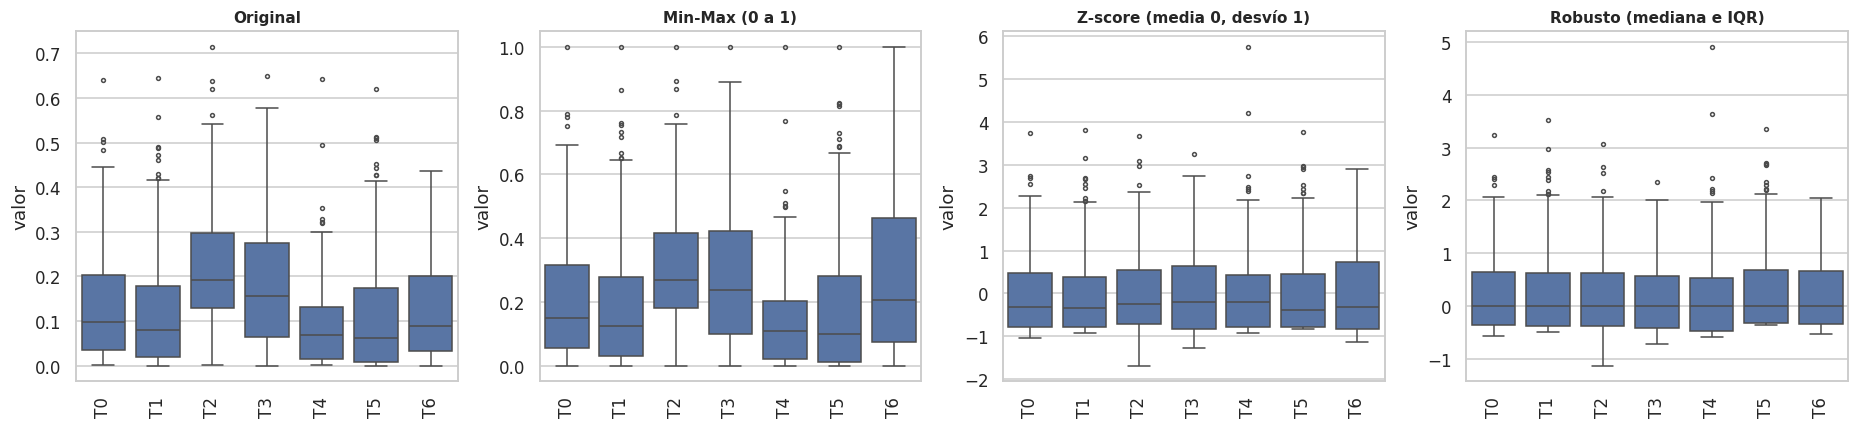

  df NO se modificó: sigue con 171 filas y 8 columnas,
  y sus valores originales (máximo global = 0.7143).


In [15]:
# --- Los escaladores ---
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# OJO: esto es una DEMOSTRACIÓN sobre una copia. No modifica df.
ejemplo = df[predictoras].copy()

mostrar = pd.DataFrame({
    "original_min": ejemplo.min(),
    "original_max": ejemplo.max(),
    "original_media": ejemplo.mean(),
    "original_desvio": ejemplo.std(),
})

minmax_demo = pd.DataFrame(MinMaxScaler().fit_transform(ejemplo),
                           columns=predictoras, index=ejemplo.index)
zscore_demo = pd.DataFrame(StandardScaler().fit_transform(ejemplo),
                           columns=predictoras, index=ejemplo.index)
robusto_demo = pd.DataFrame(RobustScaler().fit_transform(ejemplo),
                            columns=predictoras, index=ejemplo.index)

mostrar["minmax_min"] = minmax_demo.min()
mostrar["minmax_max"] = minmax_demo.max()
mostrar["zscore_media"] = zscore_demo.mean()
mostrar["zscore_desvio"] = zscore_demo.std(ddof=0)

print("=" * 88)
print("  EFECTO DE CADA ESCALADOR")
print("=" * 88)
display(mostrar)
print("  Min-Max deja todo entre 0 y 1.  Z-score deja media 0 y desvío 1.")
print("  Ninguno de los dos cambia la FORMA de la distribución: solo el eje.")

fig, ejes = plt.subplots(1, 4, figsize=(17, 4))
for eje, datos, titulo in zip(
        ejes,
        [ejemplo, minmax_demo, zscore_demo, robusto_demo],
        ["Original", "Min-Max (0 a 1)", "Z-score (media 0, desvío 1)", "Robusto (mediana e IQR)"]):
    datos_largos = datos.melt(var_name="variable", value_name="valor")
    sns.boxplot(data=datos_largos, x="variable", y="valor", ax=eje,
                color="#4c72b0", fliersize=2.5)
    eje.set_title(titulo, fontsize=10)
    eje.tick_params(axis="x", rotation=90)
    eje.set_xlabel("")
plt.tight_layout()
plt.show()

print(f"  df NO se modificó: sigue con {df.shape[0]} filas y {df.shape[1]} columnas,")
print(f"  y sus valores originales (máximo global = {df[predictoras].to_numpy().max():.4f}).")

<a id="sec-2-4"></a>
## 2.4 Las matrices X e y

Armamos las dos estructuras que va a consumir el resto del cuaderno:

- **`X`** — la matriz de variables predictoras: una fila por caso, una columna por variable.
- **`y`** — el vector objetivo, ya codificado como 0 y 1.

`X` queda **sin escalar**, a propósito. El escalado se aplica dentro de cada pipeline. El punto
siguiente explica por qué eso no es una preferencia de estilo sino una necesidad.

In [16]:
X = df[predictoras].copy()
# y quedó definido en 2.2

print("=" * 70)
print("  DATOS LISTOS PARA MODELAR")
print("=" * 70)
print(f"  X : {X.shape[0]} filas x {X.shape[1]} columnas  (SIN escalar)")
print(f"  y : {y.shape[0]} etiquetas  ->  "
      f"{int((y == 1).sum())} de clase 1 ({CLASE_POSITIVA}), "
      f"{int((y == 0).sum())} de clase 0 ({clase_negativa})")
print()
print("  Verificaciones finales:")
print(f"    Valores faltantes en X  : {int(X.isna().sum().sum())}")
print(f"    Valores faltantes en y  : {int(y.isna().sum())}")
print(f"    Columnas no numéricas   : {list(X.select_dtypes(exclude=[np.number]).columns)}")
print(f"    Filas alineadas X <-> y : {len(X) == len(y)}")
print()
display(X.head())

  DATOS LISTOS PARA MODELAR
  X : 171 filas x 7 columnas  (SIN escalar)
  y : 171 etiquetas  ->  95 de clase 1 (AFI), 76 de clase 0 (NEG)

  Verificaciones finales:
    Valores faltantes en X  : 0
    Valores faltantes en y  : 0
    Columnas no numéricas   : []
    Filas alineadas X <-> y : True



,T0,T1,T2,T3,T4,T5,T6
0,0.0228,0.2070,0.3818,0.2747,0.0003,0.1131,0.0003
1,0.0068,0.0040,0.0494,0.1765,0.0312,0.4422,0.2899
2,0.1273,0.0005,0.1998,0.3339,0.0259,0.0150,0.2976
3,0.2085,0.1278,0.0905,0.2023,0.1433,0.0004,0.2272
4,0.0004,0.3938,0.1926,0.2707,0.0004,0.0004,0.1416


---
# 3. División del dataset: entrenamiento y prueba

<a id="sec-3-1"></a>
## 3.1 Por qué hay que dividir

Entrenar un modelo es enseñarle a reconocer patrones. Para saber si **realmente** aprendió, hay que
evaluarlo con datos que no vio durante el entrenamiento.

Si usáramos los mismos datos para las dos cosas, el modelo podría parecer excelente simplemente
porque ya conocía las respuestas. Es como tomarle a alguien un examen con exactamente las mismas
preguntas que estudió: un 10 no prueba que haya entendido el tema, solo que tiene buena memoria.

Por eso la práctica estándar es partir el dataset en dos:

- **Conjunto de entrenamiento** (*training set*) — con el que el modelo ajusta sus parámetros
  internos. Suele ser el 70–80%. Cuantos más datos tenga, mejor puede identificar patrones
  complejos.
- **Conjunto de prueba** (*test set*) — reservado, se usa **una sola vez**, al final, para estimar
  cómo se comportaría el modelo con datos nuevos. Simula el "mundo real": los datos que el modelo
  va a encontrar cuando esté en producción.

Las proporciones habituales son 80/20, 70/30 o 90/10, según el tamaño del dataset. Con pocos datos
conviene dejar más para entrenar; con muchos, se puede ser más generoso con la prueba.

<a id="sec-3-2"></a>
## 3.2 La división 80/20 estratificada

Dos detalles de implementación que importan:

- **`stratify=y`** mantiene la misma proporción de clases en las dos partes. Sin esto, el azar
  podría dejar el conjunto de prueba con muchos más casos de una clase que de la otra, y la
  evaluación quedaría distorsionada. Con clases desbalanceadas es prácticamente obligatorio.
- **`random_state`** fija la aleatoriedad para que la división sea siempre la misma y los
  resultados se puedan reproducir.

In [17]:
# --- Herramienta de división ---
from sklearn.model_selection import train_test_split

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEMILLA
)

print("=" * 70)
print("  DIVISIÓN 80 / 20 ESTRATIFICADA")
print("=" * 70)
print(f"  Entrenamiento : {len(X_entrena):>4} casos  ({len(X_entrena)/len(X):.1%})")
print(f"  Prueba        : {len(X_prueba):>4} casos  ({len(X_prueba)/len(X):.1%})")
print()
print("  Reparto de clases (la estratificación lo mantiene parejo):")
print(f"    {'':>16} {CLASE_POSITIVA:>8} {clase_negativa:>8}   % positiva")
for nombre, yy in [("Dataset completo", y), ("Entrenamiento", y_entrena), ("Prueba", y_prueba)]:
    print(f"    {nombre:>16} {int((yy==1).sum()):>8} {int((yy==0).sum()):>8} "
          f"{(yy==1).mean():>11.1%}")
print()
print("  Sin stratify, el conjunto de prueba de 34 casos podría quedar con 25 de")
print("  una clase y 9 de la otra solo por azar, y las métricas serían irreales.")

  DIVISIÓN 80 / 20 ESTRATIFICADA
  Entrenamiento :  136 casos  (79.5%)
  Prueba        :   35 casos  (20.5%)

  Reparto de clases (la estratificación lo mantiene parejo):
                          AFI      NEG   % positiva
    Dataset completo       95       76       55.6%
       Entrenamiento       76       60       55.9%
              Prueba       19       16       54.3%

  Sin stratify, el conjunto de prueba de 34 casos podría quedar con 25 de
  una clase y 9 de la otra solo por azar, y las métricas serían irreales.


<a id="sec-3-3"></a>
## 3.3 La fragilidad de una sola división

Con este dataset, esa división tiene un problema serio que conviene ver antes de seguir.

**34 casos de prueba son muy pocos.** Cada acierto o error mueve el accuracy en casi 3 puntos
porcentuales. Y el resultado depende enteramente de **qué** 34 casos hayan caído del lado de la
prueba, que es cosa del azar.

Lo comprobamos: entrenamos el mismo modelo, con los mismos hiperparámetros, cambiando solamente el
`random_state` de la división. Si la estimación fuera estable, los resultados deberían ser
parecidos.

(Usamos una regresión logística solo como vehículo para la demostración. El modelo en serio,
explicado y evaluado como corresponde, viene en el punto 8 de la Parte 2B.)

  EL MISMO MODELO, 25 DIVISIONES DISTINTAS


,random_state,accuracy,f1_macro
0,0,0.8857,0.8833
1,1,0.9429,0.9428
2,2,0.8571,0.8553
3,3,0.8857,0.8833
4,4,0.9143,0.9140
5,5,0.9714,0.9711
6,6,0.8571,0.8567
7,7,0.7714,0.7667
8,8,0.8857,0.8833
9,9,0.8571,0.8553


  Accuracy mínimo : 0.7714
  Accuracy máximo : 0.9714
  Rango           : 0.2000  (20.0 puntos porcentuales)
  Media           : 0.8846
  Desvío          : 0.0544


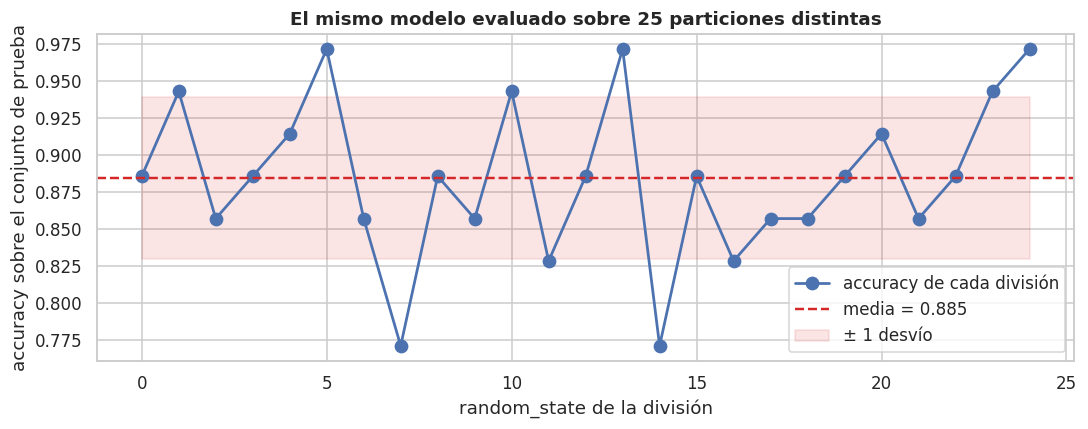


  CONCLUSIÓN: el mismo modelo, con los mismos datos y los mismos
  hiperparámetros, arroja resultados muy distintos según cómo se
  haya partido el dataset. Reportar el número de UNA división sería
  reportar en buena medida el azar.
  Esto es lo que la validación cruzada viene a resolver (punto 6).


In [18]:
# --- Solo para esta demostración ---
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

modelo_demo = Pipeline([
    ("escalador", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=5000, random_state=SEMILLA)),
])

N_DIVISIONES = 25   # el único lugar donde se elige cuántas divisiones probar

resultados_particion = []
for semilla in range(N_DIVISIONES):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, stratify=y,
                                          random_state=semilla)
    modelo_demo.fit(Xtr, ytr)
    predicho = modelo_demo.predict(Xte)
    resultados_particion.append({
        "random_state": semilla,
        "accuracy": accuracy_score(yte, predicho),
        "f1_macro": f1_score(yte, predicho, average="macro"),
    })

resultados_particion = pd.DataFrame(resultados_particion)

print("=" * 70)
print(f"  EL MISMO MODELO, {N_DIVISIONES} DIVISIONES DISTINTAS")
print("=" * 70)
display(resultados_particion)

acc = resultados_particion["accuracy"]
print(f"  Accuracy mínimo : {acc.min():.4f}")
print(f"  Accuracy máximo : {acc.max():.4f}")
print(f"  Rango           : {acc.max() - acc.min():.4f}  "
      f"({(acc.max()-acc.min())*100:.1f} puntos porcentuales)")
print(f"  Media           : {acc.mean():.4f}")
print(f"  Desvío          : {acc.std():.4f}")

fig, eje = plt.subplots(figsize=(10, 4))
eje.plot(resultados_particion["random_state"], acc, "o-", color="#4c72b0",
         linewidth=1.8, markersize=8, label="accuracy de cada división")
eje.axhline(acc.mean(), color="#d62728", linestyle="--", linewidth=1.6,
            label=f"media = {acc.mean():.3f}")
eje.fill_between(resultados_particion["random_state"],
                 acc.mean() - acc.std(), acc.mean() + acc.std(),
                 color="#d62728", alpha=0.12, label="± 1 desvío")
eje.set_xlabel("random_state de la división")
eje.set_ylabel("accuracy sobre el conjunto de prueba")
eje.set_title(f"El mismo modelo evaluado sobre {N_DIVISIONES} particiones distintas")
eje.legend()
plt.tight_layout()
plt.show()

print()
print("  CONCLUSIÓN: el mismo modelo, con los mismos datos y los mismos")
print("  hiperparámetros, arroja resultados muy distintos según cómo se")
print("  haya partido el dataset. Reportar el número de UNA división sería")
print("  reportar en buena medida el azar.")
print("  Esto es lo que la validación cruzada viene a resolver (punto 6).")

---
# 4. Fuga de información (data leakage)

<a id="sec-4-1"></a>
## 4.1 Qué es

**Fuga de información** es cualquier situación en la que el modelo tuvo acceso, directa o
indirectamente, a información del conjunto de prueba durante el entrenamiento.

La palabra clave es **indirectamente**. Nadie copia el conjunto de prueba dentro del de
entrenamiento: eso se vería enseguida. La fuga se da por caminos mucho más sutiles, y el más común
de todos es este:

> Calcular algo usando **todos** los datos, y después dividir.

Un ejemplo concreto. Querés estandarizar las variables. Calculás la media y el desvío de cada
columna sobre el dataset completo, aplicás la transformación, y recién entonces dividís en
entrenamiento y prueba. Parece razonable —todavía no entrenaste nada—, pero acabás de filtrar
información: esa media y ese desvío contienen los valores del conjunto de prueba. El modelo, al
entrenarse sobre datos transformados con esos parámetros, recibe una pista sobre cómo son los datos
que después lo van a evaluar.

La regla, en general: **cualquier cosa que se aprenda de los datos tiene que aprenderse solamente
del conjunto de entrenamiento.** Medias, desvíos, mínimos, máximos, medianas, listas de variables
seleccionadas, categorías conocidas, hiperparámetros. Todo.

<a id="sec-4-2"></a>
## 4.2 Por qué es tan grave: el síntoma es que no hay síntoma

Un error de programación tira una excepción. Un modelo mal configurado da métricas malas. La fuga
de información no hace ninguna de las dos cosas: **hace que todo se vea mejor**.

Ese es exactamente el problema. La secuencia típica es así:

1. Entrenás un modelo. Las métricas dan sorprendentemente bien: 96% de accuracy.
2. Nadie sospecha, porque un resultado bueno no se cuestiona con la misma severidad que uno malo.
3. El modelo sale a producción.
4. En producción rinde 78%.
5. Nadie entiende por qué, porque el código "es el mismo".

Y el diagnóstico es difícil justamente porque el código **es** el mismo. La diferencia está en algo
que pasó antes: un `fit_transform` aplicado dos líneas más arriba de donde correspondía.

Tres consecuencias prácticas:

- **La evaluación miente, y miente hacia arriba.** Todas las decisiones que tomes a partir de esas
  métricas —qué modelo elegir, qué variables conservar, si el proyecto sirve— están basadas en
  números inflados.
- **La comparación entre modelos se rompe.** _Si un modelo tiene fuga y otro no, el que gana es el
  que tiene fuga, no el mejor._
- **No hay alarma.** No hay error, no hay aviso, no hay nada que mirar. Solo un número lindo.

Por eso este punto tiene sección propia, y por eso la prevención tiene que ser **estructural**
—usar un `Pipeline`— y no depender de acordarse en cada caso.

<a id="sec-4-3"></a>
## 4.3 Las siete formas en que se cuela

Estas son las vías más frecuentes, ordenadas de la más común a la más sutil.

### 1. Escalar antes de dividir

La clásica. `StandardScaler().fit_transform(X)` sobre el dataset completo y después
`train_test_split`. La media y el desvío que usa la transformación contienen los datos de prueba.

**Cómo se evita:** `fit_transform` sobre el entrenamiento, `transform` sobre la prueba. O, mejor,
poner el escalador adentro de un `Pipeline`.

### 2. Imputar valores faltantes antes de dividir

Idéntico al anterior. Si imputás con la mediana de todo el dataset, esa mediana incluye las filas
de prueba.

**Cómo se evita:** `SimpleImputer` dentro del `Pipeline`.

### 3. Seleccionar variables mirando todo el dataset

Calculás la correlación de cada variable con la etiqueta usando las 171 filas, te quedás con las 10
mejores, y recién después dividís. Esa selección ya vio las etiquetas de prueba. Es la fuga **más
peligrosa de todas**, porque puede inventar señal donde no hay ninguna —lo demostramos en 4.5—.

**Cómo se evita:** `SelectKBest` dentro del `Pipeline`, o cualquier selección hecha solo con el
conjunto de entrenamiento.

### 4. Ajustar hiperparámetros contra el conjunto de prueba

Probás `max_depth` de 1 a 15, mirás cuál da mejor accuracy **en el conjunto de prueba** y te
quedás con ese. El conjunto de prueba dejó de ser independiente: lo usaste para decidir. El número
que reportás ya no es una estimación honesta.

**Cómo se evita:** tres conjuntos (entrenamiento, validación, prueba), o validación cruzada
anidada: un bucle interno que elige los hiperparámetros y uno externo que evalúa.

### 5. Duplicados repartidos entre las dos partes

Si la misma fila aparece dos veces y una copia cae en entrenamiento y la otra en prueba, el modelo
"acierta" ese caso porque lo memorizó. Con muchos duplicados, la evaluación se infla mucho. Esta es
la razón de fondo del control de duplicados de la Parte 1.

**Cómo se evita:** eliminar duplicados **antes** de dividir. Y si hay grupos naturales —varias
filas del mismo cliente, del mismo paciente, del mismo documento— hay que dividir por grupo, no
por fila: `GroupKFold`.

### 6. Variables que no existirían en el momento de predecir

Una columna que se llena *después* de que ocurre lo que querés predecir. El ejemplo clásico:
predecir si un paciente tiene una enfermedad usando como variable "medicación recetada". La
medicación se receta *porque* ya se diagnosticó. En producción esa columna estaría vacía.

Es el tipo de fuga que ningún `Pipeline` previene: hace falta entender de dónde sale cada dato y
cuándo se registra.

**Cómo se evita:** preguntar, para cada variable, *¿esto lo voy a tener en el momento en que
necesite predecir?*

### 7. Datos con orden temporal partidos al azar

Si las filas tienen fecha y partís al azar, el modelo entrena con datos de marzo y se evalúa con
datos de enero: está prediciendo el pasado con información del futuro. En producción eso nunca
pasa.

**Cómo se evita:** división temporal —entrenar con lo viejo, evaluar con lo nuevo— y
`TimeSeriesSplit` en lugar de `KFold`.

---

**En nuestro dataset**, las formas 5, 6 y 7 no aplican: no hay duplicados (lo verificamos en la
Parte 1), las siete variables se calculan todas juntas en el mismo momento, y no hay orden
temporal. Las que sí nos afectan son la **1** (el escalado), la **3** (la selección de variables) y
la **4** (el ajuste de `k` y de la poda del árbol). Las dos primeras las prevenimos con el
`Pipeline`; sobre la tercera vamos a ser honestos en las limitaciones del punto 12.8 de la Parte 2B.

<a id="sec-4-4"></a>
## 4.4 Demostración 1 — el escalador que mira de más

Empecemos por la más simple: cuánto cambian los parámetros del escalador según se los calcule con
todo el dataset o solo con el entrenamiento.

Esta demostración no muestra un desastre: muestra el **mecanismo**. Las diferencias en los
parámetros son chicas, pero son datos del conjunto de prueba que se están filtrando, y el efecto
crece cuanto más chico es el dataset y más extremos tiene.

In [19]:
# --- MAL: el escalador ve todo el dataset, incluido el conjunto de prueba ---
escalador_mal = StandardScaler().fit(X)

# --- BIEN: el escalador solo ve el conjunto de entrenamiento ---
escalador_bien = StandardScaler().fit(X_entrena)

comparacion = pd.DataFrame({
    "media_con_todo_MAL": escalador_mal.mean_,
    "media_solo_entrena_BIEN": escalador_bien.mean_,
    "dif_medias": escalador_mal.mean_ - escalador_bien.mean_,
    "desvio_con_todo_MAL": np.sqrt(escalador_mal.var_),
    "desvio_solo_entrena_BIEN": np.sqrt(escalador_bien.var_),
}, index=predictoras)
comparacion["dif_desvios"] = (comparacion["desvio_con_todo_MAL"] -
                              comparacion["desvio_solo_entrena_BIEN"])

print("=" * 88)
print("  LOS PARÁMETROS DEL ESCALADOR CAMBIAN SEGÚN QUÉ DATOS VIO")
print("=" * 88)
display(comparacion)

print("  Esas diferencias son información del conjunto de prueba filtrándose")
print("  hacia la transformación que se aplica al entrenamiento.")
print()
print(f"  Diferencia relativa máxima en las medias : "
      f"{(comparacion['dif_medias'].abs() / comparacion['media_solo_entrena_BIEN'].abs()).max():.2%}")
print(f"  Diferencia relativa máxima en los desvíos: "
      f"{(comparacion['dif_desvios'].abs() / comparacion['desvio_solo_entrena_BIEN']).max():.2%}")
print()
print("  Con Min-Max el efecto es más visible todavía, porque el mínimo y el máximo")
print("  dependen de UN SOLO valor cada uno: si el valor más alto del dataset está")
print("  en el conjunto de prueba, el escalador 'sabe' hasta dónde llegan los datos")
print("  que todavía no vio.")

minmax_todo = MinMaxScaler().fit(X)
minmax_entrena = MinMaxScaler().fit(X_entrena)
comparacion_mm = pd.DataFrame({
    "max_con_todo_MAL": minmax_todo.data_max_,
    "max_solo_entrena_BIEN": minmax_entrena.data_max_,
    "diferencia": minmax_todo.data_max_ - minmax_entrena.data_max_,
}, index=predictoras)
print()
display(comparacion_mm)
cuantas = int((comparacion_mm["diferencia"].abs() > 1e-12).sum())
print(f"  En {cuantas} de {len(predictoras)} variables, el valor máximo del dataset")
print("  está en el conjunto de PRUEBA. Escalando con todo, el modelo lo 'sabe'.")

  LOS PARÁMETROS DEL ESCALADOR CAMBIAN SEGÚN QUÉ DATOS VIO


,media_con_todo_MAL,media_solo_entrena_BIEN,dif_medias,desvio_con_todo_MAL,desvio_solo_entrena_BIEN,dif_desvios
T0,0.1401,0.1436,-0.0035,0.1340,0.1364,-0.0024
T1,0.1261,0.1321,-0.0061,0.1358,0.1400,-0.0042
T2,0.2249,0.2133,0.0116,0.1332,0.1196,0.0136
T3,0.1840,0.1870,-0.0030,0.1434,0.1458,-0.0024
T4,0.0892,0.0937,-0.0045,0.0963,0.1021,-0.0058
T5,0.1122,0.1078,0.0043,0.1348,0.1293,0.0055
T6,0.1235,0.1224,0.0011,0.1079,0.1087,-0.0009


  Esas diferencias son información del conjunto de prueba filtrándose
  hacia la transformación que se aplica al entrenamiento.

  Diferencia relativa máxima en las medias : 5.46%
  Diferencia relativa máxima en los desvíos: 11.41%

  Con Min-Max el efecto es más visible todavía, porque el mínimo y el máximo
  dependen de UN SOLO valor cada uno: si el valor más alto del dataset está
  en el conjunto de prueba, el escalador 'sabe' hasta dónde llegan los datos
  que todavía no vio.



,max_con_todo_MAL,max_solo_entrena_BIEN,diferencia
T0,0.6410,0.6410,0.0000
T1,0.6447,0.6447,0.0000
T2,0.7143,0.6205,0.0938
T3,0.6492,0.6492,0.0000
T4,0.6432,0.6432,0.0000
T5,0.6206,0.5124,0.1082
T6,0.4358,0.4358,0.0000


  En 2 de 7 variables, el valor máximo del dataset
  está en el conjunto de PRUEBA. Escalando con todo, el modelo lo 'sabe'.


<a id="sec-4-5"></a>
## 4.5 Demostración 2 — "predecir" ruido puro muy por encima del azar

Esta es la demostración que hay que ver. El escalado filtra un poco; la **selección de variables**
mirando todo el dataset puede inventar señal donde no hay absolutamente nada.

**El experimento.** Generamos 1.000 variables de **ruido aleatorio puro**. Números al azar, sin
ninguna relación con la etiqueta: por construcción, un modelo honesto no debería superar el
azar.

Después hacemos dos cosas:

- **La forma incorrecta.** Calculamos qué 20 de esas 1.000 variables se relacionan mejor con la
  etiqueta, usando **todo** el dataset. Nos quedamos con esas 20 y recién entonces hacemos
  validación cruzada.
- **La forma correcta.** Metemos la selección adentro del `Pipeline`, de modo que se rehaga en cada
  pliegue usando solo los datos de entrenamiento de ese pliegue.

**Por qué la forma incorrecta "funciona".** Con 1.000 variables al azar y 171 filas, algunas van a
parecerse a la etiqueta **por pura casualidad**. Al elegirlas mirando todo el dataset, estamos
eligiendo justamente las que coinciden con las etiquetas de prueba. El modelo después "predice"
esas etiquetas porque las variables fueron seleccionadas para coincidir con ellas.

Es exactamente lo que pasa cuando alguien reporta un resultado espectacular con un dataset de
pocas filas y muchas columnas.

  EXPERIMENTO: 1.000 VARIABLES DE RUIDO PURO, CERO SEÑAL REAL
  Filas                : 171
  Variables de ruido   : 1000
  Variables a elegir   : 20
  Accuracy esperable   : ~55.56% (la línea de base)

  RESULTADOS
  ------------------------------------------------------------------------------------
  MAL  (selección sobre todo el dataset, después validación cruzada)
       accuracy por pliegue : [0.8889 0.6471 0.8824 0.7059 0.7647 0.7647 0.7059 0.6471 0.8824 0.8824]
       MEDIA                : 0.7771   <-- con RUIDO PURO

  BIEN (selección adentro del Pipeline, rehecha en cada pliegue)
       accuracy por pliegue : [0.7222 0.7059 0.6471 0.5294 0.5882 0.6471 0.7059 0.4706 0.6471 0.5294]
       MEDIA                : 0.6193   <-- lo honesto

  DIFERENCIA: +0.1578 de accuracy
              inventados de la nada.


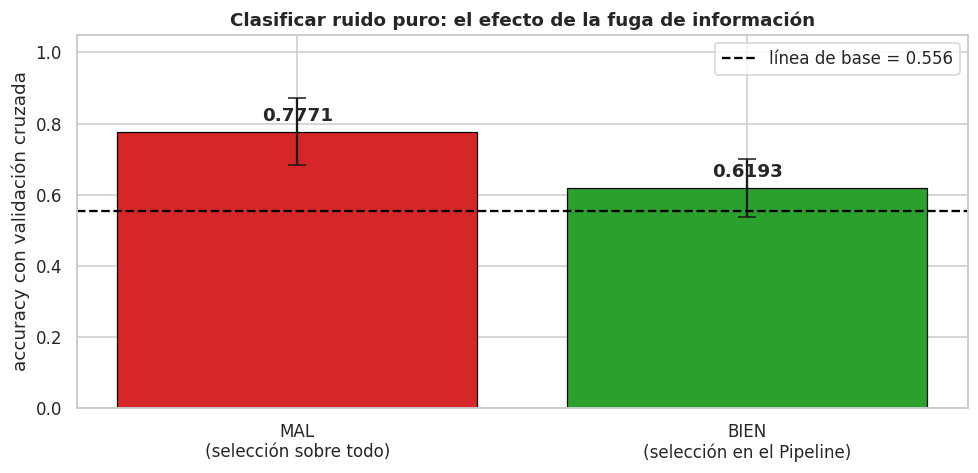


  LO QUE HAY QUE ENTENDER:
  No hay ninguna señal en esos datos. Cero. Son números al azar.
  El primer resultado es enteramente artificial, y sin embargo no hay
  ningún error, ningún aviso y ninguna forma de notarlo mirando el código
  del modelo. La fuga ocurrió TRES LÍNEAS ANTES de entrenar.


In [20]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import cross_val_score, StratifiedKFold

generador = np.random.RandomState(SEMILLA)
N_VARIABLES_RUIDO = 1000
K_SELECCIONADAS = 20

# 1.000 variables de ruido puro: ninguna relación con y
X_ruido = pd.DataFrame(
    generador.normal(size=(len(y), N_VARIABLES_RUIDO)),
    columns=[f"ruido_{i}" for i in range(N_VARIABLES_RUIDO)],
    index=y.index,
)

# El cv de las demostraciones usa los mismos pliegues que el resto del cuaderno:
# N_PLIEGUES se define una sola vez, en el punto 0.4.
cv_demo = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)

print("=" * 88)
print("  EXPERIMENTO: 1.000 VARIABLES DE RUIDO PURO, CERO SEÑAL REAL")
print("=" * 88)
print(f"  Filas                : {len(y)}")
print(f"  Variables de ruido   : {N_VARIABLES_RUIDO}")
print(f"  Variables a elegir   : {K_SELECCIONADAS}")
print(f"  Accuracy esperable   : ~{max(y.mean(), 1-y.mean()):.2%} (la línea de base)")
print()

# ---------- FORMA INCORRECTA: seleccionar mirando TODO el dataset ----------
selector_mal = SelectKBest(f_classif, k=K_SELECCIONADAS).fit(X_ruido, y)
X_ruido_elegido = X_ruido.loc[:, selector_mal.get_support()]

modelo_simple = LogisticRegression(max_iter=5000, random_state=SEMILLA)
score_mal = cross_val_score(modelo_simple, X_ruido_elegido, y,
                            cv=cv_demo, scoring="accuracy")

# ---------- FORMA CORRECTA: la selección adentro del Pipeline ----------
pipeline_bien = Pipeline([
    ("seleccion", SelectKBest(f_classif, k=K_SELECCIONADAS)),
    ("modelo", LogisticRegression(max_iter=5000, random_state=SEMILLA)),
])
score_bien = cross_val_score(pipeline_bien, X_ruido, y, cv=cv_demo, scoring="accuracy")

print("  RESULTADOS")
print("  " + "-" * 84)
print(f"  MAL  (selección sobre todo el dataset, después validación cruzada)")
print(f"       accuracy por pliegue : {np.round(score_mal, 4)}")
print(f"       MEDIA                : {score_mal.mean():.4f}   <-- con RUIDO PURO")
print()
print(f"  BIEN (selección adentro del Pipeline, rehecha en cada pliegue)")
print(f"       accuracy por pliegue : {np.round(score_bien, 4)}")
print(f"       MEDIA                : {score_bien.mean():.4f}   <-- lo honesto")
print()
print(f"  DIFERENCIA: {score_mal.mean() - score_bien.mean():+.4f} de accuracy")
print(f"              inventados de la nada.")

fig, eje = plt.subplots(figsize=(9, 4.4))
barras = eje.bar(["MAL\n(selección sobre todo)", "BIEN\n(selección en el Pipeline)"],
                 [score_mal.mean(), score_bien.mean()],
                 color=["#d62728", "#2ca02c"], edgecolor="black", linewidth=0.8,
                 yerr=[score_mal.std(), score_bien.std()], capsize=6)
eje.axhline(max(y.mean(), 1 - y.mean()), color="black", linestyle="--", linewidth=1.5,
            label=f"línea de base = {max(y.mean(), 1-y.mean()):.3f}")
for barra, valor in zip(barras, [score_mal.mean(), score_bien.mean()]):
    eje.text(barra.get_x() + barra.get_width()/2, valor + 0.03, f"{valor:.4f}",
             ha="center", fontweight="bold", fontsize=12)
eje.set_ylabel("accuracy con validación cruzada")
eje.set_title("Clasificar ruido puro: el efecto de la fuga de información")
eje.set_ylim(0, 1.05)
eje.legend()
plt.tight_layout()
plt.show()

print()
print("  LO QUE HAY QUE ENTENDER:")
print("  No hay ninguna señal en esos datos. Cero. Son números al azar.")
print("  El primer resultado es enteramente artificial, y sin embargo no hay")
print("  ningún error, ningún aviso y ninguna forma de notarlo mirando el código")
print("  del modelo. La fuga ocurrió TRES LÍNEAS ANTES de entrenar.")

<a id="sec-4-6"></a>
## 4.6 El Pipeline como antídoto

La conclusión práctica de todo esto: **no hay que confiar en acordarse**. La prevención tiene que
ser estructural.

Un **`Pipeline`** de scikit-learn encadena una serie de pasos —transformaciones y, al final, un
modelo— y los trata como un único objeto. Lo importante es cómo se comporta:

- Cuando se le pide `fit`, aplica `fit_transform` a cada transformación **con los datos que
  recibe**.
- Cuando se le pide `predict`, aplica solamente `transform`, con los parámetros que aprendió en el
  `fit`.

Y acá está la clave: cuando un `Pipeline` se pasa a una función de validación cruzada, **ese ciclo
se repite dentro de cada pliegue**. El escalador se reajusta cinco veces, cada una con el 80% de
entrenamiento de ese pliegue, y se aplica al 20% restante sin haberlo visto nunca.

La fuga deja de ser un error posible y pasa a ser imposible.

```python
# En lugar de esto, que es frágil:
X_escalado = StandardScaler().fit_transform(X)      # <-- vio todo
modelo.fit(X_escalado, y)

# Esto, que es a prueba de descuidos:
pipeline = Pipeline([
    ("escalador", StandardScaler()),
    ("modelo",    LogisticRegression()),
])
cross_val_score(pipeline, X, y, cv=cv)              # <-- reajusta en cada pliegue
```
La secuencia sería así:

```
PLIEGUE i
├── separar train y test
├── tomar SOLO train
├── StandardScaler aprende media/desvío del train
├── transforma el train
├── LogisticRegression aprende con ese train escalado
└── guardamos acceso al escalador para inspeccionarlo
```

Todo el resto de la Parte 2 usa pipelines. La función `construir_pipeline()` del punto 7.2
de la Parte 2B es
la que los arma, y ningún modelo se evalúa fuera de uno.

La celda de abajo muestra el mecanismo: los parámetros que aprende el escalador cambian en cada
pliegue, y son siempre los del 80% de entrenamiento.

In [21]:
pipeline_ejemplo = Pipeline([
    ("escalador", StandardScaler()),
    ("modelo", LogisticRegression(max_iter=5000, random_state=SEMILLA)),
])

print("=" * 88)
print("  EL ESCALADOR SE REAJUSTA EN CADA PLIEGUE")
print("=" * 88)
print(f"  {'Pliegue':>8} {'Casos de entrenamiento':>24} "
      f"{'media de ' + predictoras[0]:>26} {'desvío':>12}")

for i, (idx_tr, idx_te) in enumerate(cv_demo.split(X, y), start=1):
    pipeline_ejemplo.fit(X.iloc[idx_tr], y.iloc[idx_tr])
    escalador_pliegue = pipeline_ejemplo.named_steps["escalador"]
    print(f"  {i:>8} {len(idx_tr):>24} {escalador_pliegue.mean_[0]:>26.6f} "
          f"{np.sqrt(escalador_pliegue.var_[0]):>12.6f}")

escalador_todo = StandardScaler().fit(X)
print(f"  {'(todo)':>8} {len(X):>24} {escalador_todo.mean_[0]:>26.6f} "
      f"{np.sqrt(escalador_todo.var_[0]):>12.6f}   <-- lo que NO hay que usar")
print()
print("  Cada fila usa parámetros distintos, calculados solo con su 80% de")
print("  entrenamiento. El 20% de prueba de cada pliegue nunca participó del ajuste.")
print("  Eso es lo que hace que la estimación sea honesta.")

  EL ESCALADOR SE REAJUSTA EN CADA PLIEGUE
   Pliegue   Casos de entrenamiento                media de T0       desvío
         1                      153                   0.142066     0.133344
         2                      154                   0.142716     0.136167
         3                      154                   0.141563     0.136317
         4                      154                   0.141902     0.135602
         5                      154                   0.139514     0.132722
         6                      154                   0.137860     0.136308
         7                      154                   0.141270     0.133452
         8                      154                   0.135631     0.131312
         9                      154                   0.143635     0.136016
        10                      154                   0.134809     0.128610
    (todo)                      171                   0.140095     0.134039   <-- lo que NO hay que usar

  Cada fila usa

<a id="sec-4-7"></a>
## 4.7 Lista de control

Para aplicar antes de dar por buena cualquier evaluación:

| # | Pregunta | Si la respuesta es "no" |
|---|---|---|
| 1 | ¿El escalado está adentro de un `Pipeline`? | Moverlo adentro |
| 2 | ¿La imputación está adentro del `Pipeline`? | Moverla adentro |
| 3 | ¿La selección de variables está adentro del `Pipeline`? | Moverla adentro |
| 4 | ¿Los duplicados se eliminaron **antes** de dividir? | Eliminarlos y volver a dividir |
| 5 | ¿Hay grupos naturales (cliente, paciente, documento) repartidos entre las partes? | Usar `GroupKFold` |
| 6 | ¿Cada variable va a existir en el momento de predecir? | Sacar las que no |
| 7 | ¿Los datos tienen orden temporal? | Dividir por tiempo, `TimeSeriesSplit` |
| 8 | ¿Los hiperparámetros se eligieron mirando el conjunto de prueba? | Validación cruzada anidada |
| 9 | ¿El resultado es sospechosamente bueno? | Buscar la fuga antes de festejar |

La número 9 no es una broma. Un resultado muy por encima de lo esperable es, estadísticamente, más
veces una fuga que un hallazgo.

---
# 5. Overfitting y underfitting

Este es, junto con la fuga de información, el concepto que más decide si un modelo sirve o no.
La diferencia entre los dos es importante: la fuga es un **error de procedimiento** —se comete o
no se comete, y se evita con un `Pipeline`—, mientras que el ajuste es un **equilibrio** que hay
que buscar de nuevo en cada problema. No existe el modelo que esté bien ajustado por defecto.

Este punto es todo conceptual hasta el 5.7. Recién ahí aparece el código, y lo que hace es mostrar
en nuestros datos lo que acá se explica en general.

<a id="sec-5-1"></a>
## 5.1 Qué es cada uno

Todo modelo tiene que encontrar un equilibrio entre dos errores opuestos: **aprender de menos y
aprender de más.**

Conviene tener presente cuál es el objetivo real. No queremos un modelo que acierte los casos que
ya tenemos —esos ya vienen con la respuesta escrita al lado—. Queremos uno que acierte **casos que
todavía no existen**. A eso se le llama **generalizar**, y es la única medida de éxito que
importa.

### Overfitting (sobreajuste)

El modelo aprende **demasiado bien** los datos de entrenamiento. En lugar de captar los patrones
generales, memoriza los detalles: el ruido, los casos particulares, los errores de carga, las
casualidades de esa muestra concreta.

A simple vista parece un éxito: las predicciones sobre los datos conocidos son casi perfectas. El
problema aparece con datos nuevos, donde el modelo falla, porque los detalles que memorizó no se repiten.

**Cuándo aparece:** cuando el modelo es demasiado complejo para la cantidad de datos disponibles.
Un árbol sin límite de profundidad, un KNN con *k*=1, un bosque enorme sobre 50 filas, una red
neuronal con más parámetros que ejemplos. La palabra clave es **para la cantidad de datos**: el
mismo árbol que sobreajusta con 171 filas puede estar perfectamente ajustado con 100.000.


### Underfitting (subajuste)

El caso opuesto. El modelo **no logra captar los patrones** ni siquiera en los datos de
entrenamiento. Se equivoca en todos lados por igual.

**La analogía:** un estudiante que solo leyó el título del tema. No resuelve los ejercicios del
examen, pero tampoco los de la clase.

**Cuándo aparece:** cuando el modelo es demasiado simple para el problema —una recta para separar
datos que forman círculos concéntricos—, cuando las variables no representan bien el fenómeno, o
cuando se entrenó con muy pocas iteraciones.

**Por qué es menos peligroso:** porque se nota. Un modelo que rinde mal en todos lados no engaña a
nadie: el primer número que uno mira ya avisa. El sobreajuste, en cambio, se disfraza de éxito.

Que sea menos peligroso no quiere decir que sea aceptable. Un modelo subajustado es un modelo que
no sirve, solo que además lo dice de entrada.

### El equilibrio

Entre los dos extremos hay una zona donde el modelo aprende lo suficiente para generalizar sin
memorizar. Encontrarla es uno de los objetivos centrales de todo el proceso.


![Equilibrio entre subajuste y sobreajuste](https://raw.githubusercontent.com/FerCipriani/CursoML_Proyecto_IVE/0725680b93281348bfc5ea0b7b11e5591a6742c1/Ajuste.png)


Hay tres cosas para leer en ese gráfico:

El error de entrenamiento baja siempre que se agrega complejidad. Nunca sube. Por eso, por sí solo, no informa nada: un modelo con error de entrenamiento cero puede ser excelente o puede ser una tabla de búsqueda.
El error de validación baja y después sube. Ese cambio de dirección es el único indicador confiable, y el punto donde ocurre es el objetivo.
La distancia vertical entre las dos curvas —la brecha— se ensancha hacia la derecha. Esa distancia es lo que vamos a medir.

<a id="sec-5-2"></a>
## 5.2 El compromiso sesgo–varianza

Sobreajuste y subajuste son la cara visible de algo más general, que conviene conocer porque
explica *por qué* no se pueden evitar los dos a la vez.

El error que un modelo comete con datos nuevos se descompone en tres partes:

```
error esperado  =  sesgo²  +  varianza  +  error irreducible
```

**Sesgo (*bias*)** — cuánto se equivoca el modelo **sistemáticamente**, por ser demasiado simple
para la forma real del problema. Un modelo con mucho sesgo se equivoca siempre para el mismo lado,
sin importar con qué datos lo entrenemos. Es el subajuste visto desde adentro.

**Varianza** — cuánto **cambia el modelo** si lo entrenamos con otra muestra del mismo fenómeno.
Un modelo con mucha varianza es inestable: entrenado con estas 171 filas da una cosa, entrenado
con otras 171 igual de válidas da algo bastante distinto. Es el sobreajuste visto desde adentro.

**Error irreducible** — el ruido propio del fenómeno. Dos casos con exactamente las mismas
variables de entrada pueden tener etiquetas distintas, sencillamente porque las variables no
contienen toda la información que determina el resultado. Ningún modelo puede bajar de ahí. Si el
error irreducible de un problema es del 15 %, un modelo que reporta 98 % de accuracy no es
brillante: es sospechoso.

### La analogía del tiro al blanco

Es la que mejor fija la idea. Cada entrenamiento con una muestra distinta es un tiro:

|  | **Poca varianza** | **Mucha varianza** |
|---|---|---|
| **Poco sesgo** | Los tiros agrupados en el centro. Es el objetivo | Los tiros repartidos alrededor del centro: en promedio dan bien, pero cualquiera de ellos por separado puede estar lejos |
| **Mucho sesgo** | Los tiros agrupados, pero lejos del centro. Consistentemente equivocado | Los tiros repartidos **y** corridos. El peor de los casos |

Notá que "en promedio da bien" no consuela: en la práctica entrenamos el modelo **una sola vez**,
con los datos que tenemos. Un modelo de alta varianza es una apuesta.

### Por qué es un compromiso y no un problema con solución

Bajar el sesgo —darle más capacidad al modelo— **sube** la varianza. Bajar la varianza
—limitarlo— **sube** el sesgo. Moviendo la complejidad no se pueden minimizar los dos a la vez:
por eso se habla de un *compromiso* (*trade-off*).

Lo que sí se puede hacer es bajar los dos cambiando **otra cosa**:

| Qué cambiar | Efecto | Por qué |
|---|---|---|
| **Más datos** | Baja la varianza, no toca el sesgo | Con más ejemplos, las casualidades pesan menos y el modelo entrenado con una muestra se parece más al entrenado con otra |
| **Mejores variables** | Baja el sesgo, no toca la varianza | Si la información está mejor representada, un modelo simple alcanza. Es lo que hace valioso al feature engineering |
| **Conjuntos (*ensembles*)** | Bajan la varianza | Promediar muchos modelos de alta varianza cancela buena parte de sus errores individuales. Es exactamente la razón de ser del Random Forest del punto 11 de la Parte 2B |
| **Regularización** | Baja la varianza a cambio de algo de sesgo | Es un movimiento sobre el compromiso, no una salida de él, pero suele ser un buen negocio |

### Dónde se para cada uno de nuestros cuatro modelos

| Modelo | Sesgo | Varianza | Comentario |
|---|---|---|---|
| Regresión Logística | Alto | Baja | Solo puede dibujar un plano; la regularización L2 le baja todavía más la varianza |
| KNN con *k* grande | Alto | Baja | Promedia sobre muchos vecinos: se vuelve casi una constante |
| KNN con *k* = 1 | Muy bajo | Muy alta | Cada predicción depende de un único caso |
| Árbol sin podar | Muy bajo | Muy alta | Puede separar cada caso en su propia hoja |
| Árbol podado | Medio | Media | La poda es exactamente el mando de este compromiso |
| Random Forest | Bajo | Baja | Conserva el bajo sesgo del árbol y le cancela la varianza promediando |

Esa última fila explica por qué el Random Forest suele ganar: es el único de los cuatro que
consigue mejorar en las dos columnas a la vez, y lo logra porque no cambia la complejidad del
modelo individual sino la cantidad de modelos. El precio que paga está en otro lado: deja de ser
legible.

<a id="sec-5-3"></a>
## 5.3 Las señales: tabla de diagnóstico

La forma básica de diagnosticar es comparar el rendimiento del modelo **en los datos con los que
entrenó** contra el de **datos que no vio**. Los cuatro escenarios posibles:

| Rendimiento en entrenamiento | Rendimiento en validación | Diagnóstico | Qué está pasando | Qué hacer |
|---|---|---|---|---|
| Alto (0,99) | Bajo (0,72) | **Sobreajuste** | Memorizó | Simplificar el modelo o conseguir más datos |
| Bajo (0,65) | Bajo (0,63) | **Subajuste** | No aprendió | Dar más capacidad o mejores variables |
| Alto (0,92) | Alto (0,89) | **Correcto** | Generaliza | Nada: es el objetivo |
| Bajo (0,70) | Alto (0,85) | **Raro** | Casi siempre indica un error en el código, o una regularización que solo se aplica al entrenar | Revisar el código antes que el modelo |

Sobre la cuarta fila, que desconcierta cuando aparece: rendir **mejor** en datos que no se vieron
que en los de entrenamiento no es una buena noticia, es un síntoma. Las causas habituales son que
el conjunto de validación quedó más fácil por azar —muy común con pocos datos—, que hay filas
repetidas entre las dos partes, o que el modelo aplica una penalización o un *dropout* durante el
entrenamiento que después desactiva.


### Otras señales, menos obvias

**El modelo tiene muchos más parámetros que datos.** Un árbol con 150 hojas sobre 171 filas está prácticamente guardando una fila por hoja. La regla de bolsillo: si la cantidad de decisiones que el modelo puede tomar se acerca a la cantidad de ejemplos que vio, no está aprendiendo, está indexando.

**Los resultados cambian mucho al cambiar la semilla.** Un modelo que generaliza da resultados
parecidos con cualquier partición. Uno que memoriza depende de qué le haya tocado memorizar. Es exactamente lo que medimos en 3.3.

**El desvío entre pliegues es grande.** Si el F1 va de 0,70 a 0,95 según el pliegue, el modelo no está capturando algo estable: está reaccionando a los datos puntuales de cada partición.

**El modelo usa variables que no tienen sentido.** Si al mirar la importancia de las variables aparece arriba una que no debería importar, puede estar explotando una casualidad de la muestra.
Este es el único indicio que exige conocer el dominio, y por eso es tan valioso: ninguna métrica lo detecta.

**Las probabilidades son extremas.** Un modelo que predice 0,999 y 0,001 y casi nada en el medio suele estar demasiado seguro de sí mismo. Las métricas de calibración —*log loss* y *Brier*, que calculamos en el punto 7.3 de la Parte 2B— son sensibles a esto, mientras que el accuracy no lo nota.

### Tres cosas que parecen sobreajuste y no lo son

| Lo que se ve | Por qué no es sobreajuste |
|---|---|
| El modelo acierta el 100 % en entrenamiento | Por sí solo no dice nada. Si también acierta en validación, el problema simplemente era fácil |
| Hay una brecha de 0,04 | Con un conjunto de validación chico, una brecha de ese tamaño puede ser enteramente ruido de medición. Hay que compararla contra el desvío entre pliegues |
| El rendimiento cae al pasar a producción | Puede ser sobreajuste, pero también *data drift*: los datos nuevos ya no se parecen a los viejos. Son problemas distintos con soluciones distintas |

<a id="sec-5-4"></a>
## 5.4 Las cuatro formas de detectarlo

### Forma 1 — La brecha entre entrenamiento y validación

La más directa. Se entrena el modelo, se lo evalúa **sobre los mismos datos de entrenamiento** y
sobre datos que no vio, y se comparan los dos números.

*Cómo se lee:* la resta. Cuanto más grande, más memoriza.

*Qué la hace útil:* es inmediata y no requiere nada especial. Debería ser el primer número que uno
mira de cualquier modelo.

*Su límite:* con una sola partición, la medición es ruidosa. Como vimos en 3.3, el resultado sobre
34 casos de prueba se mueve varios puntos según el azar. Una brecha de 0,05 puede ser sobreajuste
o puede ser la partición que le tocó.

### Forma 2 — La curva de validación

Se repite el entrenamiento variando **un hiperparámetro que controla la complejidad** —la
profundidad del árbol, el *k* de KNN, la fuerza de la regularización— y se grafican las dos
curvas: rendimiento en entrenamiento y en validación, contra complejidad.

*Cómo se lee:*

- La curva de entrenamiento **sube siempre**: más complejidad, más capacidad de memorizar.
- La de validación sube hasta un punto y después **baja**.
- El punto donde las dos se separan marca el comienzo del sobreajuste.
- El máximo de la curva de validación marca la complejidad justa.
- Si las dos curvas están bajas y juntas en toda la izquierda del gráfico, eso es subajuste.

*Qué la hace útil:* no dice solo "hay sobreajuste", dice **dónde empieza** y **cuánta complejidad
conviene**. Es una herramienta de diagnóstico y de ajuste a la vez.

*Su límite:* mira un hiperparámetro por vez. Si la complejidad está repartida entre varios —la
profundidad *y* el mínimo de casos por hoja, por ejemplo—, la curva de uno solo puede engañar. Ahí
conviene una búsqueda en grilla, que es lo que usamos con el árbol en el punto 10 de la Parte 2B.

### Forma 3 — El desvío entre pliegues de la validación cruzada

En lugar de una partición, se usan cinco o diez, y se mira no solo la media sino la **dispersión**
de los resultados.

*Cómo se lee:* un desvío chico significa que el modelo rinde parecido sin importar qué datos le
toquen —está capturando algo estable—. Un desvío grande significa que el rendimiento depende de la
partición, que es otra forma de decir que el modelo está reaccionando a particularidades de los
datos y no a un patrón general.

*Qué la hace útil:* es la única de las cuatro que da una **medida del error de la medición**. Sin
ella no se puede saber si la diferencia entre dos modelos es real. Es la que vamos a usar en toda la comparativa del punto 12 de la Parte 2B.

*Su límite:* no distingue entre un modelo inestable y un dataset chico. Con 171 filas, cierto
desvío es inevitable venga el modelo que venga.

### Forma 4 — La curva de aprendizaje

Grafica el rendimiento contra la **cantidad de datos** en lugar de contra la complejidad. Se entrena el mismo modelo con el 20 %, el 30 %, el 40 %… de los datos disponibles, y en cada tamaño se miden las dos curvas.

Responde una pregunta distinta de las anteriores, y muy práctica: ***¿conviene conseguir más datos?***

*Cómo se lee:*

- Si las dos curvas **convergen y se aplanan** en un valor bajo, más datos no van a ayudar: el   problema es el modelo. Hay **sesgo alto** y lo que hace falta es un modelo más expresivo o mejores variables.
- Si las dos curvas **siguen separadas** y la de validación todavía viene subiendo en el extremo derecho, más datos sí ayudarían. Hay **varianza alta**.
- Si la curva de entrenamiento arranca en 1,0 y se mantiene ahí, el modelo memoriza desde el primer momento.

*Qué la hace útil:* es la única que informa sobre una decisión que está **fuera del modelo** —ir a buscar más datos, que suele ser lo más caro del proyecto— y la única que distingue con claridad un problema de sesgo de uno de varianza.

*Su límite:* es la más cara de calcular, porque entrena el modelo muchas veces sobre muchos tamaños.

### Las cuatro, resumidas

| Forma | Contra qué grafica | Qué pregunta responde | Costo |
|---|---|---|---|
| Brecha | nada, es un número | ¿Hay sobreajuste? | Nulo |
| Curva de validación | complejidad | ¿Cuánta complejidad conviene? | Medio |
| Desvío entre pliegues | nada, es un número | ¿Cuánto vale esta medición? | Bajo |
| Curva de aprendizaje | cantidad de datos | ¿Conviene conseguir más datos? | Alto |

Las cuatro se usan en este cuaderno: la 1 y la 2 en los puntos 5.7 y 5.8, la 4 en el 5.9, y la 3
en todo el resto, desde el punto 6 hasta el final.

<a id="sec-5-5"></a>
## 5.5 Cómo se mide: la brecha y sus umbrales

La **brecha** es la medida más usada:

```
brecha = rendimiento en entrenamiento - rendimiento en validación
```

Cuanto más grande, más memoriza el modelo. Pero *cuánto* es mucho no tiene una respuesta
universal: depende del tamaño del dataset, del problema y de qué métrica se use.

Algunas referencias prácticas, que son convenciones y no leyes:

| Brecha (en F1 o accuracy) | Lectura habitual |
|---|---|
| Menor a 0,02 | Sin señales de sobreajuste |
| 0,02 a 0,05 | Normal, sobre todo en datasets chicos |
| 0,05 a 0,10 | Aviso: conviene no aumentar más la complejidad |
| Mayor a 0,10 | Sobreajuste que hay que atender |
| Mayor a 0,20 | El modelo está memorizando |

Y tres cosas que la brecha sola no dice:

**El nivel.** Una brecha de 0,01 con un F1 de 0,60 en validación no es un buen modelo: es un
modelo que aprende poco y de manera consistente. Por eso hay que mirar **brecha y nivel juntos**.

**El error de medición.** Una brecha de 0,04 medida sobre 34 casos no es distinguible de una de
0,00. Con pocos datos, la brecha hay que estimarla con validación cruzada y compararla contra el
desvío entre pliegues. Si la brecha es menor que el desvío, no está demostrada.

**Con qué métrica se calculó.** La brecha en accuracy y la brecha en F1 macro del mismo modelo
pueden ser bastante distintas, sobre todo si las clases están desbalanceadas. Hay que decir
siempre con cuál se midió. En este cuaderno usamos **F1 macro**, porque trata a las dos clases por
igual.

En este cuaderno los umbrales están declarados en la configuración del punto 0.4:

```python
BRECHA_SOBREAJUSTE = 0.10   # por encima: se avisa sobreajuste
DESVIO_INESTABLE   = 0.08   # por encima: se avisa inestabilidad
SCORE_SUBAJUSTE    = 0.70   # por debajo: se avisa subajuste
```

Y la función `diagnosticar_ajuste()` del punto 7.3 de la Parte 2B los aplica automáticamente a cada modelo. Están
arriba de todo, con nombre, justamente para que se puedan discutir y cambiar en lugar de quedar
escondidos en el medio del código. Si te parecen mal calibrados para este problema, cambiarlos es
una línea y todo el cuaderno se recalcula.

<a id="sec-5-6"></a>
## 5.6 Qué hacer con cada uno

Los dos problemas tienen remedios **opuestos**. Por eso diagnosticar bien es la mitad del trabajo:
aplicar el remedio equivocado empeora las cosas. Bajarle la profundidad a un árbol que ya estaba
subajustado lo empeora dos veces.

### Contra el subajuste: darle más capacidad al modelo

| Remedio | En concreto | Cuándo es el correcto |
|---|---|---|
| Usar un modelo más expresivo | Pasar de una regresión logística a un árbol o un bosque | Cuando la frontera real no es lineal |
| Aumentar la complejidad | Subir `max_depth`, bajar `k` en KNN, subir `C` (menos regularización) | Cuando el modelo elegido está frenado por sus hiperparámetros |
| Mejorar las variables | Feature engineering: crear variables que representen mejor el fenómeno | Cuando hay información latente que el modelo no puede deducir solo |
| Entrenar más | Más iteraciones, más árboles | Cuando el entrenamiento se cortó antes de converger |
| Revisar la limpieza | A veces el problema es que se eliminó información valiosa al "limpiar" | Cuando el rendimiento empeoró justo después de limpiar |

### Contra el sobreajuste: limitar al modelo o darle más datos

| Remedio | En concreto | Cuándo es el correcto |
|---|---|---|
| Simplificar el modelo | Bajar `max_depth`, subir `min_samples_leaf`, subir `k` en KNN | Casi siempre, y es lo primero que conviene probar |
| Regularizar | Penalizar los coeficientes grandes: bajar `C` en la regresión logística | En modelos lineales y en redes |
| Conseguir más datos | El remedio más eficaz de todos, y casi siempre el menos disponible | Cuando la curva de aprendizaje (5.4, forma 4) muestra que todavía sube |
| Reducir variables | Menos columnas, menos oportunidades de encontrar casualidades | Cuando hay muchas más variables que filas |
| Usar conjuntos (*ensembles*) | Un bosque promedia muchos árboles y cancela buena parte del sobreajuste individual | Cuando el modelo base es bueno pero inestable |
| Parada temprana | En modelos iterativos, cortar cuando el error de validación deja de bajar | En *boosting* y redes neuronales |
| Validar bien | La validación cruzada no evita el sobreajuste, pero lo hace visible | Siempre |

### Dónde se sobreajusta cada uno de nuestros cuatro modelos

Esta tabla es el puente entre este punto y los puntos 8 a 11 de la Parte 2B: dice, para cada modelo, cuál es el
mando que controla su complejidad y hacia qué lado hay que moverlo.

| Modelo | El mando | Sobreajusta cuando | Subajusta cuando | Valor por defecto en scikit-learn |
|---|---|---|---|---|
| **Regresión Logística** | `C` (inverso de la regularización) | `C` muy alto, o hay más variables que filas | `C` muy bajo | `C=1.0`, regularización L2 moderada. Sobreajusta poco de fábrica |
| **KNN** | `n_neighbors` (*k*) | *k* = 1: cada predicción depende de un solo vecino | *k* comparable al tamaño del dataset | `k=5`. Es el modelo donde el mando se ve más claro |
| **Árbol de Decisión** | `max_depth` y `min_samples_leaf` | Sin límite de profundidad: puede aislar cada caso en su hoja | Profundidad 1 o 2 | **Sin límites**: sobreajusta por defecto. Hay que podarlo a mano |
| **Random Forest** | `n_estimators`, `max_features`, `max_depth` | Rara vez, y nunca por agregar árboles | Profundidad muy limitada | Sin límite de profundidad, pero el promedio lo compensa |

Dos observaciones que vale la pena retener:

- **El árbol es el único que sobreajusta por defecto.** Un `DecisionTreeClassifier()` recién
  sacado de la caja crece hasta separar cada caso. Por eso en el punto 10 de la Parte 2B buscamos la poda con una
  grilla, mientras que a la logística no le tocamos nada.
- **En el Random Forest, agregar árboles nunca empeora.** Más árboles es siempre mejor o igual, y
  solo cuesta tiempo. Es la excepción a la regla de que más complejidad trae sobreajuste, y la
  razón es que los árboles no se suman: se promedian.

### Un caso particular: la regularización

Vale detenerse porque es el remedio más usado y el menos intuitivo. Regularizar es agregarle a la
función que el modelo minimiza un término que **penaliza la complejidad**. El modelo deja de
buscar solamente el mejor ajuste y pasa a buscar un equilibrio entre ajustar bien y mantenerse
simple.

En términos del punto 5.2: la regularización **compra varianza barata a cambio de sesgo caro**.
Empeora un poco el ajuste sobre los datos que ya tenemos, a cambio de que el modelo no cambie
tanto con datos nuevos. En datasets chicos ese intercambio casi siempre conviene.

Las dos formas habituales:

| Penalización | Qué penaliza | Efecto característico |
|---|---|---|
| **L2** (*Ridge*) | La suma de los coeficientes **al cuadrado** | Achica todos los coeficientes de manera pareja; ninguno llega a cero |
| **L1** (*Lasso*) | La suma de los **valores absolutos** | Lleva algunos coeficientes exactamente a cero: selecciona variables sola |

En la regresión logística se controla con el parámetro `C`, que es el **inverso** de la fuerza de
la penalización: valores chicos regularizan **más** —coeficientes más chicos, modelo más simple— y
valores grandes regularizan menos. Es una convención que confunde a todo el mundo la primera vez.

Por defecto scikit-learn usa `C=1.0` con penalización L2, que es una regularización moderada y
**siempre activa**. Es, entre otras cosas, lo que hace que la regresión logística funcione bien en
datasets chicos sin necesidad de ajustar nada.

<a id="sec-5-7"></a>
## 5.7 En código: tres niveles de complejidad

Con los conceptos claros, vamos a verlos en nuestros datos.

Tomamos el mismo modelo —un árbol de decisión— en tres niveles de complejidad: uno **sin límite de
profundidad**, que puede memorizar cada caso; uno de **profundidad 3**; y uno de **profundidad 1**,
que solo puede hacer una pregunta. Los tres se entrenan con los mismos datos y se evalúan sobre el
entrenamiento y sobre la prueba.

Esta es la **forma 1** de 5.4: la brecha. Lo que esperamos ver, si todo lo anterior es cierto:

- El árbol sin límite debería acertar **todo** en entrenamiento y bastante menos en prueba.
- El de profundidad 3 debería quedar en el medio, con una brecha chica.
- El de profundidad 1 debería tener una brecha mínima pero un nivel bajo —subajuste—.

La columna `hojas` de la tabla es la que hace visible el mecanismo: dice en cuántos grupos terminó
partiendo el árbol los datos de entrenamiento.

  TRES NIVELES DE COMPLEJIDAD


,modelo,hojas,profundidad,accuracy_entrenamiento,accuracy_prueba,brecha
0,Árbol sin límite (complejo),13,6,1.0000,0.8000,0.2000
1,Árbol de profundidad 3 (medio),8,3,0.9485,0.7714,0.1771
2,Árbol de profundidad 1 (simple),2,1,0.8309,0.7143,0.1166


  Árbol sin límite (complejo)        -> brecha 0.200: SOBREAJUSTE  |  nivel 0.800: aceptable
  Árbol de profundidad 3 (medio)     -> brecha 0.177: SOBREAJUSTE  |  nivel 0.771: aceptable
  Árbol de profundidad 1 (simple)    -> brecha 0.117: SOBREAJUSTE  |  nivel 0.714: aceptable

  Notá la columna 'hojas': el árbol sin límite llegó a 13 hojas
  para 136 casos de entrenamiento, es decir unos 10.5 casos por hoja,
  y con eso alcanza para acertarlos TODOS (accuracy de entrenamiento = 1,000).
  Eso es memorizar, no aprender.

  ADVERTENCIA IMPORTANTE sobre estos números:
  el accuracy de prueba está medido sobre 35 casos. Cada acierto
  o error vale 2.9 puntos, así que las tres brechas de esta tabla
  tienen un margen de error grande. Sirven para ver el PATRÓN —más
  complejidad, más brecha— pero no para decidir nada con precisión.
  En el punto 6 vamos a volver a medirlo como corresponde.


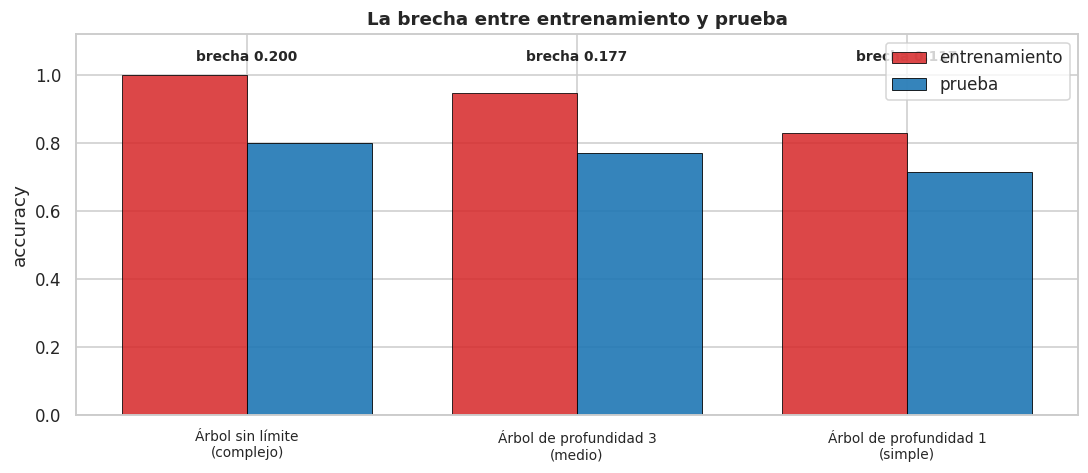

In [22]:
from sklearn.tree import DecisionTreeClassifier

ejemplos = {
    "Árbol sin límite (complejo)":     DecisionTreeClassifier(random_state=SEMILLA),
    "Árbol de profundidad 3 (medio)":  DecisionTreeClassifier(max_depth=3, random_state=SEMILLA),
    "Árbol de profundidad 1 (simple)": DecisionTreeClassifier(max_depth=1, random_state=SEMILLA),
}

comparacion_ajuste = []
for nombre, estimador in ejemplos.items():
    estimador.fit(X_entrena, y_entrena)
    acc_tr = accuracy_score(y_entrena, estimador.predict(X_entrena))
    acc_te = accuracy_score(y_prueba, estimador.predict(X_prueba))
    comparacion_ajuste.append({
        "modelo": nombre,
        "hojas": estimador.get_n_leaves(),
        "profundidad": estimador.get_depth(),
        "accuracy_entrenamiento": acc_tr,
        "accuracy_prueba": acc_te,
        "brecha": acc_tr - acc_te,
    })

comparacion_ajuste = pd.DataFrame(comparacion_ajuste)

print("=" * 96)
print("  TRES NIVELES DE COMPLEJIDAD")
print("=" * 96)
display(comparacion_ajuste)

for _, fila in comparacion_ajuste.iterrows():
    partes = []
    if fila["brecha"] > BRECHA_SOBREAJUSTE:
        partes.append(f"brecha {fila['brecha']:.3f}: SOBREAJUSTE")
    elif fila["brecha"] > BRECHA_SOBREAJUSTE / 2:
        partes.append(f"brecha {fila['brecha']:.3f}: sobreajuste leve")
    else:
        partes.append(f"brecha {fila['brecha']:.3f}: aceptable")
    if fila["accuracy_prueba"] < SCORE_SUBAJUSTE:
        partes.append(f"nivel {fila['accuracy_prueba']:.3f}: bajo, señal de SUBAJUSTE")
    else:
        partes.append(f"nivel {fila['accuracy_prueba']:.3f}: aceptable")
    print(f"  {fila['modelo']:<34} -> {'  |  '.join(partes)}")

print()
casos_por_hoja = len(X_entrena) / comparacion_ajuste.loc[0, "hojas"]
print(f"  Notá la columna 'hojas': el árbol sin límite llegó a "
      f"{comparacion_ajuste.loc[0, 'hojas']} hojas")
print(f"  para {len(X_entrena)} casos de entrenamiento, es decir unos "
      f"{casos_por_hoja:.1f} casos por hoja,")
print("  y con eso alcanza para acertarlos TODOS (accuracy de entrenamiento = 1,000).")
print("  Eso es memorizar, no aprender.")
print()
print("  ADVERTENCIA IMPORTANTE sobre estos números:")
print(f"  el accuracy de prueba está medido sobre {len(X_prueba)} casos. Cada acierto")
print(f"  o error vale {100/len(X_prueba):.1f} puntos, así que las tres brechas de esta tabla")
print("  tienen un margen de error grande. Sirven para ver el PATRÓN —más")
print("  complejidad, más brecha— pero no para decidir nada con precisión.")
print("  En el punto 6 vamos a volver a medirlo como corresponde.")

fig, eje = plt.subplots(figsize=(10, 4.4))
posiciones = np.arange(len(comparacion_ajuste))
ancho = 0.38
eje.bar(posiciones - ancho/2, comparacion_ajuste["accuracy_entrenamiento"], ancho,
        label="entrenamiento", color="#d62728", alpha=0.85, edgecolor="black", linewidth=0.6)
eje.bar(posiciones + ancho/2, comparacion_ajuste["accuracy_prueba"], ancho,
        label="prueba", color="#1f77b4", alpha=0.9, edgecolor="black", linewidth=0.6)
eje.set_xticks(posiciones)
eje.set_xticklabels([m.replace(" (", "\n(") for m in comparacion_ajuste["modelo"]], fontsize=9)
eje.set_ylabel("accuracy")
eje.set_ylim(0, 1.12)
eje.set_title("La brecha entre entrenamiento y prueba")
eje.legend()
for i, fila in comparacion_ajuste.iterrows():
    eje.text(i, 1.04, f"brecha {fila['brecha']:.3f}", ha="center", fontsize=9,
             fontweight="bold")
plt.tight_layout()
plt.show()

<a id="sec-5-8"></a>
## 5.8 La curva de validación

Ahora la **forma 2** de 5.4. Repetimos el experimento anterior variando la profundidad del árbol
de 1 a 15 y graficamos las dos curvas, para ver el recorrido completo en lugar de tres puntos
sueltos.

Acá la hacemos con la división simple 80/20, que es lo único que tenemos hasta este punto del
cuaderno. Sale muy temblorosa la curva de prueba: sube y baja de manera errática. Eso **no** es el comportamiento del modelo, es el ruido de estar midiendo sobre 34 casos.

En el punto 6.4 vamos a repetir exactamente este gráfico con validación cruzada, y la diferencia va a ser evidente. Es la mejor justificación de por qué hace falta.

  CURVA DE VALIDACIÓN con una sola división 80/20


,max_depth,entrenamiento,prueba,brecha
0,1,0.8250,0.7024,0.1226
1,2,0.9094,0.7667,0.1427
2,3,0.9470,0.7667,0.1803
3,4,0.9850,0.7697,0.2153
4,5,0.9925,0.7420,0.2505
5,6,1.0000,0.7974,0.2026
6,7,1.0000,0.7974,0.2026
7,8,1.0000,0.7974,0.2026
8,9,1.0000,0.7974,0.2026
9,10,1.0000,0.7974,0.2026


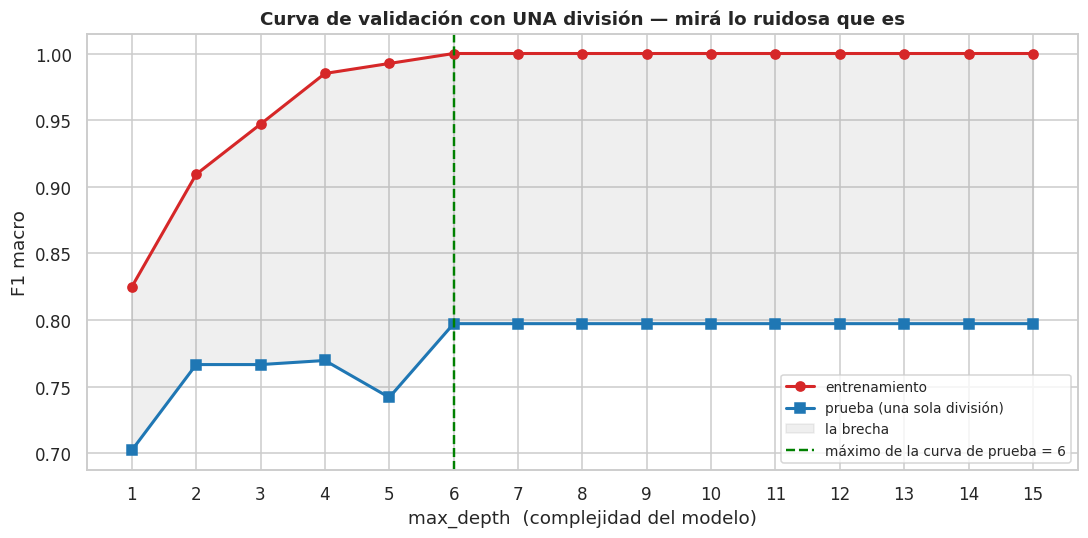

  Qué se ve:
    - La curva roja (entrenamiento) sube siempre hasta llegar a 1,0 y quedarse.
      Más profundidad = más capacidad de memorizar.
    - La curva azul (prueba) sube, baja, vuelve a subir. Ese zigzag NO es el
      modelo: es el ruido de medir sobre 34 casos.
    - El área gris es la brecha, que se ensancha hacia la derecha.

  Con esta curva, ¿cuál es la profundidad óptima? El máximo está en 6,
  pero con tanto ruido es difícil confiar en ese número. Lo repetimos en 6.4
  con validación cruzada.


In [23]:
profundidades = list(range(1, 16))
curva_simple = []

for prof in profundidades:
    arbol = DecisionTreeClassifier(max_depth=prof, random_state=SEMILLA)
    arbol.fit(X_entrena, y_entrena)
    curva_simple.append({
        "max_depth": prof,
        "entrenamiento": f1_score(y_entrena, arbol.predict(X_entrena), average="macro"),
        "prueba": f1_score(y_prueba, arbol.predict(X_prueba), average="macro"),
    })

curva_simple = pd.DataFrame(curva_simple)
curva_simple["brecha"] = curva_simple["entrenamiento"] - curva_simple["prueba"]

print("=" * 78)
print("  CURVA DE VALIDACIÓN con una sola división 80/20")
print("=" * 78)
display(curva_simple)

fig, eje = plt.subplots(figsize=(10, 5))
eje.plot(curva_simple["max_depth"], curva_simple["entrenamiento"], "o-",
         color="#d62728", linewidth=2, label="entrenamiento")
eje.plot(curva_simple["max_depth"], curva_simple["prueba"], "s-",
         color="#1f77b4", linewidth=2, label="prueba (una sola división)")
eje.fill_between(curva_simple["max_depth"], curva_simple["prueba"],
                 curva_simple["entrenamiento"], color="grey", alpha=0.12,
                 label="la brecha")
mejor_simple = int(curva_simple.loc[curva_simple["prueba"].idxmax(), "max_depth"])
eje.axvline(mejor_simple, color="green", linestyle="--", linewidth=1.6,
            label=f"máximo de la curva de prueba = {mejor_simple}")
eje.set_xlabel("max_depth  (complejidad del modelo)")
eje.set_ylabel("F1 macro")
eje.set_title("Curva de validación con UNA división — Muy ruidosa!")
eje.set_xticks(profundidades)
eje.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("  Qué se ve:")
print("    - La curva roja (entrenamiento) sube siempre hasta llegar a 1,0 y quedarse.")
print("      Más profundidad = más capacidad de memorizar.")
print("    - La curva azul (prueba) sube, baja, vuelve a subir. Ese zigzag NO es el")
print("      modelo: es el ruido de medir sobre 34 casos.")
print("    - El área gris es la brecha, que se ensancha hacia la derecha.")
print()
print(f"  Con esta curva, ¿cuál es la profundidad óptima? El máximo está en {mejor_simple},")
print("  pero con tanto ruido es difícil confiar en ese número. Lo repetimos en 6.4")
print("  con validación cruzada.")

<a id="sec-5-9"></a>
## 5.9 La curva de aprendizaje

La última de las cuatro formas, y la que responde una pregunta distinta: **¿conviene conseguir más
datos?**

En lugar de variar la complejidad del modelo, variamos la **cantidad de datos**: entrenamos el
mismo modelo con el 20 %, el 30 %, el 40 %… hasta el 100 % de las filas disponibles, y en cada
tamaño medimos el rendimiento en entrenamiento y en validación cruzada.

Ponemos uno al lado del otro los dos diagnósticos opuestos del punto 5.2:

| Panel | Modelo | Qué buscamos ver |
|---|---|---|
| Izquierda | Árbol **sin límite** de profundidad | **Varianza alta**: la curva de entrenamiento clavada en 1,0 desde el primer tramo y la de validación bastante más abajo. La distancia entre las dos es el síntoma |
| Derecha | Regresión logística con `C=0.0001` | **Sesgo alto**: las dos curvas juntas y planas en un valor bajo. No hay distancia entre ellas porque el modelo no aprende ni siquiera los datos que ve |

**Por qué hay que arruinar un modelo a propósito.** El de la derecha está deliberadamente
estropeado: `C=0.0001` es una regularización brutal que aplasta todos los coeficientes contra cero
y deja al modelo respondiendo prácticamente siempre lo mismo. Hizo falta hacerlo porque **en este
dataset es difícil conseguir subajuste de manera natural**: la señal es tan clara que hasta un
árbol de una sola pregunta rinde bien, como se vio en 5.7. Eso ya es un dato sobre el problema, y
es una buena noticia; pero para ilustrar el sesgo alto hay que fabricarlo.

De paso, es la demostración práctica de lo que dijimos en 5.6 sobre la regularización: `C` chico
compra estabilidad a cambio de sesgo, y llevado al extremo el negocio deja de convenir.

**Qué mirar en cada curva:**

- **La distancia vertical entre las dos líneas** al final del recorrido. Grande ⇒ varianza alta.
- **La altura a la que terminan.** Baja y juntas ⇒ sesgo alto.
- **La pendiente de la línea azul en el tramo final.** Si todavía sube, más datos ayudarían; si ya
  se aplanó, el modelo llegó a su techo con los datos que tiene.

Una advertencia sobre lo que sigue: con 171 filas, los tramos de la izquierda se calculan sobre muy
pocos casos y salen ruidosos. La banda sombreada muestra ese ruido. Hay que leer la **forma** de
las curvas, no cada punto por separado.

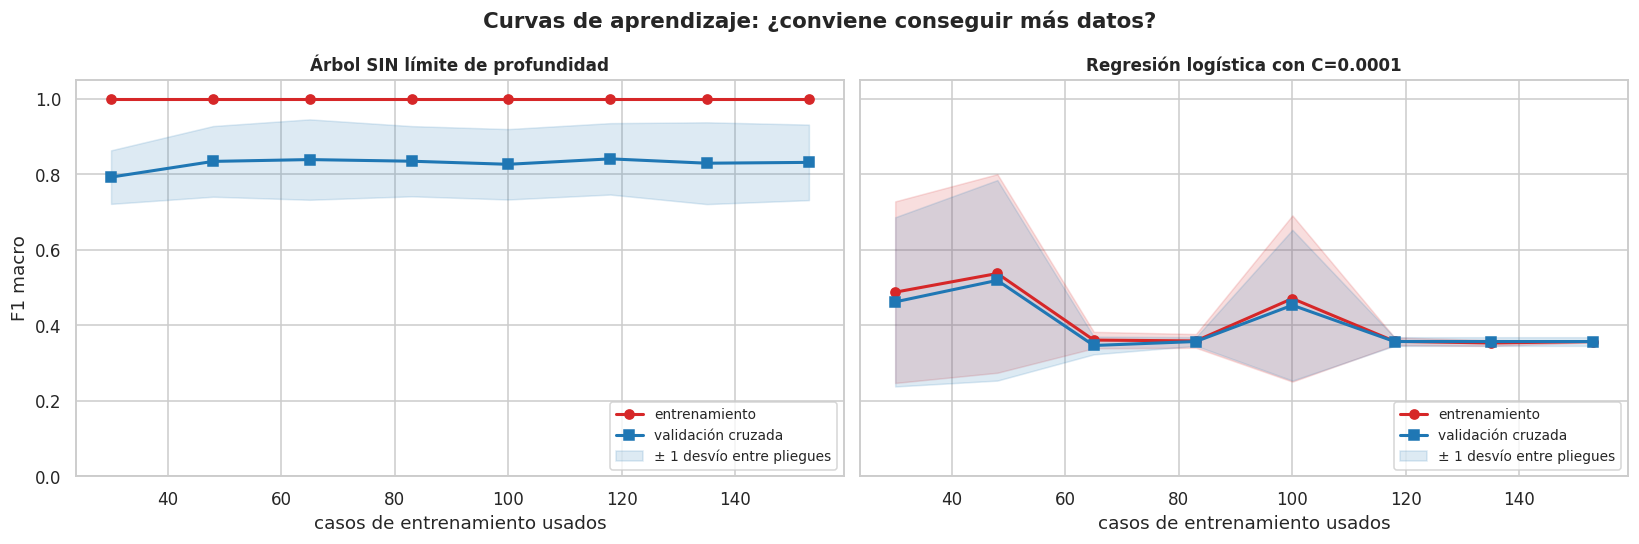

  LECTURA DE LAS CURVAS DE APRENDIZAJE


,modelo,f1_entrena_final,f1_validacion_final,brecha_final,tendencia_tramo_final,ruido_tipico
0,Árbol SIN límite de profundidad,1.0000,0.8311,0.1689,0.0013,0.0949
1,Regresión logística con C=0.0001,0.3569,0.3569,-0.0001,-0.0872,0.0948


  Árbol SIN límite de profundidad
      Con todos los datos : entrenamiento 1.0000, validación 0.8311
      Brecha final        : 0.1689
      Tendencia del tramo final : +0.0013 (ruido típico 0.0949)
      La curva de validación YA SE APLANÓ
      >> VARIANZA ALTA pero la curva ya se aplanó. Más datos moverían poco:
         lo primero que conviene probar es simplificar el modelo (podarlo).

  Regresión logística con C=0.0001
      Con todos los datos : entrenamiento 0.3569, validación 0.3569
      Brecha final        : -0.0001
      Tendencia del tramo final : -0.0872 (ruido típico 0.0948)
      La curva de validación YA SE APLANÓ
      >> SESGO ALTO. Las dos curvas juntas y bajas: el modelo no aprende
         ni siquiera los datos que ve. Más datos NO ayudarían; hace falta
         un modelo más expresivo, menos regularización o mejores variables.

  DOS COSAS PARA NOTAR
  ----------------------------------------------------------------------------------------
  1. El árbol sin pod

In [24]:
from sklearn.model_selection import learning_curve

modelos_curva = [
    ("Árbol SIN límite de profundidad",
     DecisionTreeClassifier(random_state=SEMILLA)),
    ("Regresión logística con C=0.0001",
     Pipeline([("escalador", StandardScaler()),
               ("modelo", LogisticRegression(C=0.0001, max_iter=5000,
                                             random_state=SEMILLA))])),
]

proporciones = np.linspace(0.2, 1.0, 8)

fig, ejes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
lectura = []

for eje, (titulo, estimador) in zip(ejes, modelos_curva):
    n_casos, score_tr, score_val = learning_curve(
        estimador, X, y,
        cv=cv_demo,
        scoring="f1_macro",
        train_sizes=proporciones,
        shuffle=True,
        random_state=SEMILLA,
        n_jobs=1,
    )
    media_tr, desvio_tr = score_tr.mean(axis=1), score_tr.std(axis=1)
    media_val, desvio_val = score_val.mean(axis=1), score_val.std(axis=1)

    eje.plot(n_casos, media_tr, "o-", color="#d62728", linewidth=2,
             label="entrenamiento")
    eje.fill_between(n_casos, media_tr - desvio_tr, media_tr + desvio_tr,
                     color="#d62728", alpha=0.15)
    eje.plot(n_casos, media_val, "s-", color="#1f77b4", linewidth=2,
             label="validación cruzada")
    eje.fill_between(n_casos, media_val - desvio_val, media_val + desvio_val,
                     color="#1f77b4", alpha=0.15, label="± 1 desvío entre pliegues")
    eje.set_title(titulo, fontsize=11)
    eje.set_xlabel("casos de entrenamiento usados")
    eje.legend(fontsize=9, loc="lower right")

    # Tendencia del tramo final: pendiente por mínimos cuadrados sobre los
    # últimos cuatro puntos, expresada como cuánto subiría a lo largo de ese tramo.
    pendiente = np.polyfit(n_casos[-4:], media_val[-4:], 1)[0]
    tendencia = pendiente * (n_casos[-1] - n_casos[-4])

    lectura.append({
        "modelo": titulo,
        "f1_entrena_final": media_tr[-1],
        "f1_validacion_final": media_val[-1],
        "brecha_final": media_tr[-1] - media_val[-1],
        "tendencia_tramo_final": tendencia,
        "ruido_tipico": desvio_val.mean(),
    })

ejes[0].set_ylabel("F1 macro")
ejes[0].set_ylim(0, 1.05)
fig.suptitle("Curvas de aprendizaje: ¿conviene conseguir más datos?",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

lectura = pd.DataFrame(lectura)
print("=" * 92)
print("  LECTURA DE LAS CURVAS DE APRENDIZAJE")
print("=" * 92)
display(lectura)

for _, fila in lectura.iterrows():
    sube = fila["tendencia_tramo_final"] > fila["ruido_tipico"] / 2
    print(f"  {fila['modelo']}")
    print(f"      Con todos los datos : entrenamiento {fila['f1_entrena_final']:.4f}, "
          f"validación {fila['f1_validacion_final']:.4f}")
    print(f"      Brecha final        : {fila['brecha_final']:.4f}")
    print(f"      Tendencia del tramo final : {fila['tendencia_tramo_final']:+.4f} "
          f"(ruido típico {fila['ruido_tipico']:.4f})")
    print(f"      La curva de validación {'TODAVÍA SUBE' if sube else 'YA SE APLANÓ'}")

    if fila["f1_validacion_final"] < SCORE_SUBAJUSTE:
        print("      >> SESGO ALTO. Las dos curvas juntas y bajas: el modelo no aprende")
        print("         ni siquiera los datos que ve. Más datos NO ayudarían; hace falta")
        print("         un modelo más expresivo, menos regularización o mejores variables.")
    elif fila["brecha_final"] > BRECHA_SOBREAJUSTE and sube:
        print("      >> VARIANZA ALTA y la curva todavía sube: MÁS DATOS AYUDARÍAN.")
    elif fila["brecha_final"] > BRECHA_SOBREAJUSTE:
        print("      >> VARIANZA ALTA pero la curva ya se aplanó. Más datos moverían poco:")
        print("         lo primero que conviene probar es simplificar el modelo (podarlo).")
    else:
        print("      >> Las dos curvas convergen en un valor razonable: el modelo está")
        print("         aprovechando bien los datos que tiene.")
    print()

print("  DOS COSAS PARA NOTAR")
print("  " + "-" * 88)
print("  1. El árbol sin podar alcanza su techo de validación con muy pocos casos y")
print("     después se queda ahí, mientras su curva de entrenamiento está clavada en")
print("     1,0 desde el principio. Esa distancia que no se cierra es la firma de la")
print("     varianza alta: el modelo no necesita más datos para aprender el patrón,")
print("     necesita que lo frenen para que deje de aprender también el ruido.")
print()
print("  2. El modelo sobre-regularizado tiene las dos curvas pegadas, y eso que a")
print("     veces se lee como 'no hay sobreajuste' acá no vale nada: están pegadas")
print("     abajo. Es el recordatorio del punto 5.5 de que la brecha sin el nivel no")
print("     alcanza para diagnosticar.")
print()
print("  CÓMO SE USA ESTO EN LA PRÁCTICA")
print("  " + "-" * 88)
print("  Conseguir más datos suele ser lo más caro de un proyecto: hay que recolectarlos,")
print("  etiquetarlos y validarlos. Esta es la única de las cuatro formas de diagnóstico")
print("  que informa sobre esa decisión ANTES de tomarla, y la única que distingue con")
print("  claridad un problema de sesgo de uno de varianza.")

---
# 6. Validación cruzada K-Fold

<a id="sec-6-1"></a>
## 6.1 Cómo funciona

El punto 3.3 mostró el problema: la evaluación depende de cómo se partió el dataset. El punto 5
mostró qué buscamos detectar. La **validación cruzada** resuelve las dos cosas.

En lugar de partir el dataset una sola vez, se lo divide en *K* partes llamadas **pliegues**
(*folds*). Después se entrena *K* veces: en cada vuelta, un pliegue distinto hace de conjunto de
prueba y los otros *K-1* de entrenamiento.

```
   Pliegue 1:  [PRUEBA][entrena][entrena][entrena][entrena]
   Pliegue 2:  [entrena][PRUEBA][entrena][entrena][entrena]
   Pliegue 3:  [entrena][entrena][PRUEBA][entrena][entrena]
   Pliegue 4:  [entrena][entrena][entrena][PRUEBA][entrena]
   Pliegue 5:  [entrena][entrena][entrena][entrena][PRUEBA]
```

El esquema dibujado usa cinco pliegues para que entre en la página; el valor real lo fija
`N_PLIEGUES` en el punto 0.4.

Así **cada caso del dataset es evaluado exactamente una vez**, por un modelo que no lo vio durante
su entrenamiento. Al final se tienen *K* mediciones: su **media** es la estimación del rendimiento,
y su **desvío** dice cuán confiable es esa estimación.

<a id="sec-6-2"></a>
## 6.2 Cuántos pliegues, y por qué acá no es opcional

Tres razones concretas, no genéricas:

**1. El dataset es chico.** Con 171 filas, un conjunto de prueba del 20% son 34 casos. Ya vimos en
3.3 que la estimación se mueve varios puntos de un `random_state` a otro, y en 5.8 que la curva de
validación sale ilegible de tan ruidosa. La validación cruzada usa las 171 filas para evaluar, no
34.

**2. Vamos a comparar cuatro modelos y tres escalados.** Doce combinaciones. Si las diferencias
entre ellas son de unos pocos puntos y la medición tiene un ruido del mismo orden, la comparación
no significa nada. La validación cruzada da, además de la media, el **desvío entre pliegues**, que
es lo que permite decir si una diferencia observada es real o cabe dentro del ruido. Sin esa
segunda cifra, un ranking de modelos es una lista de casualidades ordenadas.

**3. No se desperdicia ningún dato.** Cada caso participa del entrenamiento en *K-1* vueltas y de
la evaluación en una. Con 171 filas, reservar 34 y no usarlas nunca para entrenar es un lujo que no
nos podemos dar.

**Estratificada, además.** Usamos `StratifiedKFold`, que arma los pliegues manteniendo en cada uno
la misma proporción de clases que el dataset completo. Sin estratificar, algún pliegue podría
quedar con un reparto muy distinto y su métrica sería poco representativa.

### Cuántos pliegues

**La cantidad de pliegues es un solo parámetro: `N_PLIEGUES`, en el punto 0.4.** De ahí lo toma todo
el cuaderno —el objeto `cv`, las demostraciones de los puntos 4 y 5, los encabezados de las tablas y
los títulos de los gráficos—. No hay ningún `5` ni ningún `10` escrito en otra celda, así que
cambiarlo ahí arriba cambia el cuaderno entero, y la Parte 2B lo declara igual en su propio 0.3.

Con 171 filas las dos opciones razonables son:

| K | Entrena por vuelta | Evalúa por pliegue | A favor | En contra |
|---|---|---|---|---|
| **5** | ~137 casos (80 %) | ~34 casos | La mitad de tiempo de cómputo, y cada medición individual se hace sobre una muestra más grande, así que el desvío entre pliegues es más estable | Estimación levemente más pesimista: el modelo entrena con menos datos de los que en realidad tiene disponibles |
| **10** | ~154 casos (90 %) | ~17 casos | Estimación menos sesgada, porque cada modelo entrena con casi todo el dataset | Más varianza entre pliegues —17 casos por medición— y el doble de ajustes que hacer |

Lo que **no** cambia entre las dos es cuántos datos se usan: en los dos casos las 171 filas se
evalúan exactamente una vez. Lo que cambia es en cuántos pedazos se reparte esa evaluación, y por lo
tanto cuánto ruido tiene cada pedazo. El valor con el que viene configurado este cuaderno lo imprime
la celda del punto 0.4, y la celda de 6.3 lo muestra pliegue por pliegue.

¿Y el extremo, K = número de filas (*leave-one-out*)? Cada pliegue evalúa sobre un solo caso. Es
insesgado pero extremadamente ruidoso y 171 veces más caro.

<a id="sec-6-3"></a>
## 6.3 El esquema estratificado

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=N_PLIEGUES, shuffle=True, random_state=SEMILLA)

print("=" * 78)
print(f"  ESQUEMA DE VALIDACIÓN: StratifiedKFold con {N_PLIEGUES} pliegues")
print("=" * 78)
print(f"  {'Pliegue':>8} {'Entrena':>9} {'Prueba':>8} {'% pos. entrena':>16} {'% pos. prueba':>15}")
for i, (idx_tr, idx_te) in enumerate(cv.split(X, y), start=1):
    print(f"  {i:>8} {len(idx_tr):>9} {len(idx_te):>8} "
          f"{y.iloc[idx_tr].mean():>15.1%} {y.iloc[idx_te].mean():>15.1%}")
print()
print(f"  Proporción de la clase positiva en el dataset completo: {y.mean():.1%}")
print("  La estratificación la mantiene casi idéntica en todos los pliegues.")

  ESQUEMA DE VALIDACIÓN: StratifiedKFold con 10 pliegues
   Pliegue   Entrena   Prueba   % pos. entrena   % pos. prueba
         1       153       18           55.6%           55.6%
         2       154       17           55.2%           58.8%
         3       154       17           55.2%           58.8%
         4       154       17           55.2%           58.8%
         5       154       17           55.2%           58.8%
         6       154       17           55.8%           52.9%
         7       154       17           55.8%           52.9%
         8       154       17           55.8%           52.9%
         9       154       17           55.8%           52.9%
        10       154       17           55.8%           52.9%

  Proporción de la clase positiva en el dataset completo: 55.6%
  La estratificación la mantiene casi idéntica en todos los pliegues.


<a id="sec-6-4"></a>
## 6.4 Una división contra validación cruzada

Dos comparaciones que cierran el argumento.

**La primera:** el mismo modelo evaluado de las dos formas.

In [32]:
modelo_demo.fit(X_entrena, y_entrena)
una_division = f1_score(y_prueba, modelo_demo.predict(X_prueba), average="macro")

resultado_cv = cross_validate(modelo_demo, X, y, cv=cv, scoring="f1_macro",
                              return_train_score=True)
por_pliegue = resultado_cv["test_score"]

print("=" * 78)
print("  UNA DIVISIÓN vs. VALIDACIÓN CRUZADA   (F1 macro)")
print("=" * 78)
print(f"  Una sola división 80/20 : {una_division:.4f}   <- un número solo, sin idea del error")
print()
print("  Validación cruzada, pliegue por pliegue:")
for i, s in enumerate(por_pliegue, start=1):
    print(f"      pliegue {i} : {s:.4f}")
print()
print(f"  Media                   : {por_pliegue.mean():.4f}")
print(f"  Desvío entre pliegues   : {por_pliegue.std():.4f}")
print(f"  Rango                   : {por_pliegue.min():.4f} a {por_pliegue.max():.4f}")
print()
print(f"  ESTIMACIÓN FINAL: {por_pliegue.mean():.4f} ± {por_pliegue.std():.4f}")
print()
print("  Esa segunda cifra es la que permite decir si una diferencia entre dos")
print("  modelos es real o si entra dentro del ruido de la medición.")
print("  De acá en adelante, TODA evaluación del cuaderno se hace así.")

  UNA DIVISIÓN vs. VALIDACIÓN CRUZADA   (F1 macro)
  Una sola división 80/20 : 0.8250   <- un número solo, sin idea del error

  Validación cruzada, pliegue por pliegue:
      pliegue 1 : 0.8889
      pliegue 2 : 0.7984
      pliegue 3 : 0.8132
      pliegue 4 : 0.8235
      pliegue 5 : 0.9377
      pliegue 6 : 0.8786
      pliegue 7 : 0.9412
      pliegue 8 : 0.9404
      pliegue 9 : 0.9412
      pliegue 10 : 1.0000

  Media                   : 0.8963
  Desvío entre pliegues   : 0.0637
  Rango                   : 0.7984 a 1.0000

  ESTIMACIÓN FINAL: 0.8963 ± 0.0637

  Esa segunda cifra es la que permite decir si una diferencia entre dos
  modelos es real o si entra dentro del ruido de la medición.
  De acá en adelante, TODA evaluación del cuaderno se hace así.


**La segunda:** la curva de validación de 5.8, rehecha con validación cruzada.

Es el mismo gráfico, el mismo modelo y el mismo rango de profundidades. Lo único que cambia es cómo
se mide cada punto: antes, con una sola división de 34 casos; ahora, con el promedio de los pliegues, y con una banda que muestra el desvío entre ellos.

Compará las dos curvas azules. La de 5.8 zigzaguea y su máximo es prácticamente arbitrario. Esta
tiene una forma clara: sube, llega a un máximo, y baja. Y la banda sombreada dice, en cada punto,
cuánta confianza merece ese valor.

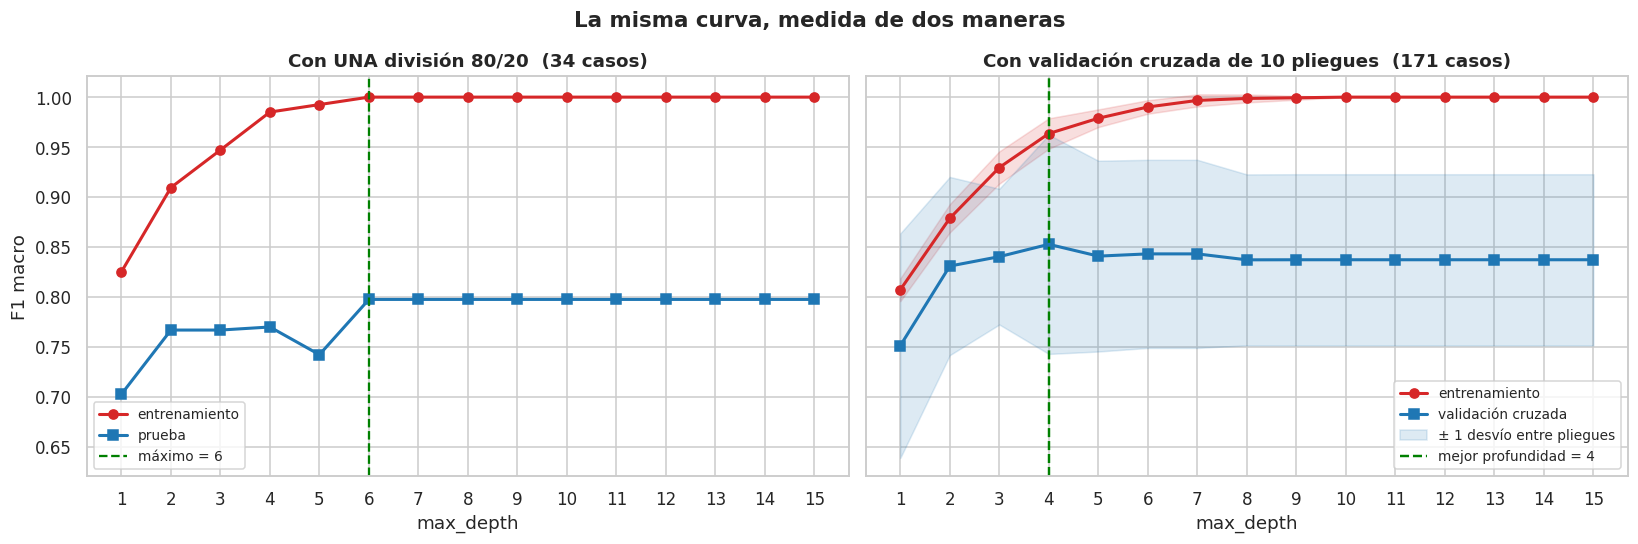

  LECTURA DE LA CURVA CON VALIDACIÓN CRUZADA
  Zona de SUBAJUSTE   : max_depth de 1 a 3
  Mejor complejidad   : max_depth = 4  (F1 macro = 0.8526 ± 0.1098)
  Zona de SOBREAJUSTE : max_depth mayor a 4

  Brecha en el óptimo : 0.1109
  Brecha en el extremo: 0.1629  (max_depth = 15)

  La curva de una sola división daba como óptimo max_depth = 6;
  la validación cruzada da 4. La segunda merece mucha más confianza:
  está promediando 10 mediciones en lugar de reportar una.

  Y la banda sombreada agrega algo que la curva de la izquierda no tenía:
  una medida de cuánta confianza merece cada punto.


In [33]:
from sklearn.model_selection import validation_curve

scores_tr, scores_val = validation_curve(
    DecisionTreeClassifier(random_state=SEMILLA),
    X, y,
    param_name="max_depth",
    param_range=profundidades,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
)

media_tr, desvio_tr = scores_tr.mean(axis=1), scores_tr.std(axis=1)
media_val, desvio_val = scores_val.mean(axis=1), scores_val.std(axis=1)
mejor = int(np.argmax(media_val))
mejor_profundidad = profundidades[mejor]

fig, ejes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Izquierda: la de 5.8, con una sola división
ejes[0].plot(curva_simple["max_depth"], curva_simple["entrenamiento"], "o-",
             color="#d62728", linewidth=2, label="entrenamiento")
ejes[0].plot(curva_simple["max_depth"], curva_simple["prueba"], "s-",
             color="#1f77b4", linewidth=2, label="prueba")
ejes[0].axvline(mejor_simple, color="green", linestyle="--", linewidth=1.5,
                label=f"máximo = {mejor_simple}")
ejes[0].set_title("Con UNA división 80/20  (34 casos)")
ejes[0].set_xlabel("max_depth"); ejes[0].set_ylabel("F1 macro")
ejes[0].set_xticks(profundidades)
ejes[0].legend(fontsize=9)

# Derecha: con validación cruzada
ejes[1].plot(profundidades, media_tr, "o-", color="#d62728", linewidth=2,
             label="entrenamiento")
ejes[1].fill_between(profundidades, media_tr - desvio_tr, media_tr + desvio_tr,
                     color="#d62728", alpha=0.15)
ejes[1].plot(profundidades, media_val, "s-", color="#1f77b4", linewidth=2,
             label="validación cruzada")
ejes[1].fill_between(profundidades, media_val - desvio_val, media_val + desvio_val,
                     color="#1f77b4", alpha=0.15, label="± 1 desvío entre pliegues")
ejes[1].axvline(mejor_profundidad, color="green", linestyle="--", linewidth=1.6,
                label=f"mejor profundidad = {mejor_profundidad}")
ejes[1].set_title(f"Con validación cruzada de {N_PLIEGUES} pliegues  (171 casos)")
ejes[1].set_xlabel("max_depth")
ejes[1].set_xticks(profundidades)
ejes[1].legend(fontsize=9)

fig.suptitle("La misma curva, medida de dos maneras", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("=" * 78)
print("  LECTURA DE LA CURVA CON VALIDACIÓN CRUZADA")
print("=" * 78)
print(f"  Zona de SUBAJUSTE   : max_depth de 1 a {max(1, mejor_profundidad - 1)}")
print(f"  Mejor complejidad   : max_depth = {mejor_profundidad}  "
      f"(F1 macro = {media_val[mejor]:.4f} ± {desvio_val[mejor]:.4f})")
print(f"  Zona de SOBREAJUSTE : max_depth mayor a {mejor_profundidad}")
print()
print(f"  Brecha en el óptimo : {media_tr[mejor] - media_val[mejor]:.4f}")
print(f"  Brecha en el extremo: {media_tr[-1] - media_val[-1]:.4f}  (max_depth = {profundidades[-1]})")
print()
print(f"  La curva de una sola división daba como óptimo max_depth = {mejor_simple};")
print(f"  la validación cruzada da {mejor_profundidad}. La segunda merece mucha más confianza:")
print(f"  está promediando {N_PLIEGUES} mediciones en lugar de reportar una.")
print()
print("  Y la banda sombreada agrega algo que la curva de la izquierda no tenía:")
print("  una medida de cuánta confianza merece cada punto.")

---
<a id="sec-export"></a>
# Exportar el estado para la Parte 2B

<a id="sec-export-1"></a>
## Los archivos que deja este cuaderno

Este cuaderno termina acá y la Parte 2B sigue con los modelos. Entre los dos hay un archivo, igual
que entre la Parte 1 y este: cada etapa consume lo que produjo la anterior y deja su propio
artefacto.

**Qué se le hizo realmente a los datos.** Menos de lo que parece, y conviene tenerlo claro antes de
decidir qué exportar:

| Punto | Qué se hizo | ¿Modificó los datos? |
|---|---|---|
| 0.3 | Verificación de la entrada | No |
| 2.1 | Variables derivadas: construidas, medidas y descartadas | No |
| 2.2 | **Codificación de la etiqueta a 0 y 1** | **Sí** |
| 2.3 | Normalización y estandarización | No: se demostraron sobre una copia |
| 2.4 | Armado de las matrices `X` e `y` | Reorganiza, no transforma |
| 3 a 6 | Divisiones, fugas, curvas, pliegues | No: todo sobre copias |

Así que **el único cambio real es la codificación de la etiqueta**. El escalado no se aplica acá a
propósito: depende del modelo, y en la Parte 2B va adentro de un `Pipeline` que lo reajusta en cada
pliegue. Guardar los datos sin escalar es lo que pide el punto 4.6, y deja la decisión abierta.

| Archivo | Qué contiene | ¿Lo lee la Parte 2B? |
|---|---|---|
| `datos_modelado.csv` | La etiqueta original, las siete predictoras y la etiqueta codificada | **Sí** |
| `metadatos_parte2a.txt` | El registro de qué se decidió y con qué configuración | No: es para vos |

**Por qué el CSV lleva la etiqueta dos veces.** Va `TAG` con el texto original *y* `y` con el 0/1.
Con `y` sola alcanzaría para entrenar, pero conservar las dos permite que la Parte 2B **verifique**
que su clase positiva configurada coincide con la codificación del archivo, en lugar de darlo por
sentado. Con una sola columna de ceros y unos esa verificación sería imposible: un 1 no dice si
quiso decir `AFI` o `NEG`.

**Por qué no hace falta un archivo de configuración.** La lista de predictoras no está escrita en
ninguna parte: son, por definición, las columnas que no son ni `TAG` ni `y`, y así es como la Parte
2B las recupera. Eso tiene una consecuencia útil: si algún día descomentás las dos líneas del final
de 2.1, el CSV sale con diez columnas en lugar de siete y la Parte 2B las toma sin que haya que
tocarle nada. La semilla y los umbrales, en cambio, son **decisiones**, no datos: se vuelven a
declarar en el punto 0.3 de la Parte 2B, en una sola celda, y quedan a la vista de quien lee.

Exportamos en **CSV** y no en Excel por las mismas tres razones que en la Parte 1: lo lee cualquier
herramienta sin librerías extra, pesa menos, y no guarda formatos ni fórmulas que puedan confundirse
con datos. Con `index=False`, para que Pandas no agregue una columna con el número de fila.

In [28]:
from datetime import datetime

ARCHIVO_MODELADO  = "datos_modelado.csv"
ARCHIVO_METADATOS = "metadatos_parte2a.txt"

# --- 1. La matriz de modelado: etiqueta original + predictoras + etiqueta codificada ---
COLUMNA_CODIFICADA = "y"

modelado = X.copy()                        # las predictoras, sin escalar
modelado.insert(0, objetivo, df[objetivo]) # TAG, para poder verificar la codificación
modelado[COLUMNA_CODIFICADA] = y           # el 0/1 que produjo el punto 2.2
modelado.to_csv(ARCHIVO_MODELADO, index=False, encoding="utf-8")

# --- 2. El registro del proceso (no lo lee nadie: es documentación) ---
with open(ARCHIVO_METADATOS, "w", encoding="utf-8") as archivo:
    archivo.write("METADATOS DEL MODELADO — Parte 2A\n")
    archivo.write("=" * 68 + "\n")
    archivo.write(f"Fecha                 : {datetime.now():%Y-%m-%d %H:%M:%S}\n")
    archivo.write(f"Archivo de origen     : {RUTA_DATOS}\n")
    archivo.write(f"Filas                 : {len(modelado)}\n")
    archivo.write(f"Columna objetivo      : {objetivo}\n")
    archivo.write(f"Columna codificada    : {COLUMNA_CODIFICADA}\n")
    archivo.write(f"Clases                : {clases}\n")
    archivo.write(f"Codificación          : {mapa_clases}\n")
    archivo.write(f"Clase positiva        : {CLASE_POSITIVA}\n")
    archivo.write(f"Variables predictoras : {predictoras}\n")
    archivo.write(f"Línea de base         : {linea_base:.4f} "
                  f"(responder siempre '{clase_mayoritaria}')\n")
    archivo.write("\nConfiguración a replicar en la Parte 2B (punto 0.3):\n")
    archivo.write(f"  SEMILLA            = {SEMILLA}\n")
    archivo.write(f'  CLASE_POSITIVA     = "{CLASE_POSITIVA}"\n')
    archivo.write(f"  N_PLIEGUES         = {N_PLIEGUES}\n")
    archivo.write(f"  BRECHA_SOBREAJUSTE = {BRECHA_SOBREAJUSTE}\n")
    archivo.write(f"  DESVIO_INESTABLE   = {DESVIO_INESTABLE}\n")
    archivo.write(f"  SCORE_SUBAJUSTE    = {SCORE_SUBAJUSTE}\n")
    archivo.write("\nDecisiones tomadas en esta parte:\n")
    archivo.write("  - Se codificó la etiqueta a 0/1 fijando la clase positiva a mano (2.2).\n")
    archivo.write("  - NO se aplicó escalado: va adentro del Pipeline, por pliegue (2.3, 4.6).\n")
    archivo.write("  - NO se agregaron variables derivadas: se midieron y se descartaron (2.1).\n")
    archivo.write("  - NO se eliminó ninguna fila ni ninguna columna.\n")
    archivo.write("  - Toda evaluación posterior va con validación cruzada estratificada (6).\n")

SALIDAS = [ARCHIVO_MODELADO, ARCHIVO_METADATOS]

print("=" * 78)
print("  ARCHIVOS GENERADOS")
print("=" * 78)
print(f"  {ARCHIVO_MODELADO:<24} {modelado.shape[0]:>4} filas x {modelado.shape[1]} columnas")
print(f"  {ARCHIVO_METADATOS:<24} registro del proceso")
print()
print(f"  Columnas del CSV : {list(modelado.columns)}")
print()

# --- Verificación: releemos lo que escribimos y lo comparamos con lo que teníamos ---
control = pd.read_csv(ARCHIVO_MODELADO)
predictoras_releidas = [c for c in control.columns
                        if c not in (objetivo, COLUMNA_CODIFICADA)]

print("  VERIFICACIÓN DE LO ESCRITO")
print("  " + "-" * 74)
print(f"    Mismas dimensiones al releer      : "
      f"{control.shape == modelado.shape}")
print(f"    Predictoras recuperables del CSV  : "
      f"{predictoras_releidas == list(predictoras)}")
print(f"    Valores numéricos idénticos       : "
      f"{np.allclose(control[predictoras].to_numpy(), X.to_numpy())}")
print(f"    Etiqueta codificada idéntica      : "
      f"{bool((control[COLUMNA_CODIFICADA].to_numpy() == y.to_numpy()).all())}")
print(f"    La codificación se puede auditar  : "
      f"{bool(((control[objetivo] == CLASE_POSITIVA) == (control[COLUMNA_CODIFICADA] == 1)).all())}")
print(f"    Sin nulos                         : {int(control.isna().sum().sum()) == 0}")
print()
print("  La última línea es la que importa: la Parte 2B va a hacer exactamente esa")
print("  comprobación al abrir el archivo, y así detecta si quedó configurada con la")
print("  otra clase como positiva.")

  ARCHIVOS GENERADOS
  datos_modelado.csv        171 filas x 9 columnas
  metadatos_parte2a.txt    registro del proceso

  Columnas del CSV : ['TAG', 'T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6', 'y']

  VERIFICACIÓN DE LO ESCRITO
  --------------------------------------------------------------------------
    Mismas dimensiones al releer      : True
    Predictoras recuperables del CSV  : True
    Valores numéricos idénticos       : True
    Etiqueta codificada idéntica      : True
    La codificación se puede auditar  : True
    Sin nulos                         : True

  La última línea es la que importa: la Parte 2B va a hacer exactamente esa
  comprobación al abrir el archivo, y así detecta si quedó configurada con la
  otra clase como positiva.


<a id="sec-export-2"></a>
## Cómo llevártelos

Si estás en Colab, los archivos se escribieron en el disco de la máquina virtual, que es
**temporal**: cuando la sesión se desconecta, desaparecen. Hay que moverlos a algún lado que
persista.

| Si la Parte 2B la vas a correr... | Guardá los archivos en... |
|---|---|
| En Colab, más tarde o en otra sesión | Google Drive |
| En tu computadora, con Jupyter o VS Code | Descargados a tu disco |
| Ahora mismo, sin cerrar la sesión | Donde están; la máquina virtual los conserva |
| Y querés que se abra sin configurar nada | Subilos al repositorio de GitHub, al lado de `dataset_limpio.csv` |

La última fila es la que usa la opción A de la Parte 2B: si `datos_modelado.csv` está en el
repositorio, la Parte 2B se abre y se ejecuta sin que nadie tenga que subir nada.

Descomentá la opción que corresponda.

In [29]:
# ---------------------------------------------------------------------
# LLEVARSE LOS ARCHIVOS
# ---------------------------------------------------------------------
# La lista SALIDAS quedó armada en la celda anterior.

# --- Opción 1: copiarlos a Google Drive ---
# import shutil, os
# from google.colab import drive
# drive.mount("/content/drive")
#
# CARPETA_DESTINO = "/content/drive/MyDrive/datasets"
# os.makedirs(CARPETA_DESTINO, exist_ok=True)
# for archivo in SALIDAS:
#     shutil.copy(archivo, CARPETA_DESTINO)
#     print(f"Copiado: {archivo}")

# --- Opción 2: descargarlos a tu computadora ---
# from google.colab import files
# for archivo in SALIDAS:
#     files.download(archivo)

# --- Opción 3: empaquetar todo en un zip y bajar uno solo ---
import shutil
shutil.make_archive("salidas_parte2a", "zip", ".", base_dir=None)
from google.colab import files
files.download("salidas_parte2a.zip")

print("Archivos listos:")
for archivo in SALIDAS:
    print(f"    {archivo}")
print()
print("Si estás en Colab, acordate de llevártelos antes de cerrar la sesión.")
print("La Parte 2B empieza leyendo 'datos_modelado.csv'.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Archivos listos:
    datos_modelado.csv
    metadatos_parte2a.txt

Si estás en Colab, acordate de llevártelos antes de cerrar la sesión.
La Parte 2B empieza leyendo 'datos_modelado.csv'.


---
<a id="sec-cierre"></a>
# Cierre — Resumen de la Parte 2A

**El recorrido**

| Punto | Qué se hizo |
|---|---|
| 0.2 a 0.5 | Carga del dataset limpio, revalidación de la entrada y configuración global |
| 1 | Marco: supervisado vs. no supervisado, regresión vs. clasificación, diagnóstico del problema |
| 2 | Feature engineering evaluado y descartado, codificación de la etiqueta, escaladores, matrices `X` e `y` |
| 3 | División 80/20 estratificada, y la demostración de que una sola división no alcanza |
| 4 | Fuga de información: siete formas, dos demostraciones y el `Pipeline` como antídoto |
| 5 | Sobreajuste y subajuste: sesgo y varianza, cuatro formas de detectarlo, cómo se mide, qué hacer |
| 6 | Validación cruzada K-Fold estratificada, y la comparación directa contra una sola división |
| Exportar | `datos_modelado.csv` y el registro del proceso |

**Las decisiones que se tomaron, y por qué**

1. **No se eliminó ningún dato.** Ni outliers ni casos raros: la auditoría de la Parte 1 mostró que
   todos los valores son válidos, y con 171 filas cada caso pesa demasiado como para descartarlo sin
   una razón fuerte.
2. **No se agregaron variables derivadas.** Se construyeron, se midieron y se descartaron: no
   traían información que no estuviera ya en las siete originales (2.1).
3. **La clase positiva se fijó a mano.** No se dejó al orden alfabético de `LabelEncoder`, porque
   precisión, recall y F1 se calculan respecto de ella (2.2).
4. **No se aplicó escalado a los datos exportados.** Va adentro del `Pipeline`, que lo reajusta en
   cada pliegue. Es la única forma de garantizar que no haya fuga (2.3 y 4.6).
5. **De acá en adelante todo se evalúa con validación cruzada.** Una sola división 80/20 sobre este
   dataset da resultados que varían varios puntos según el azar de la partición (3.3 y 6.4).
6. **Se reporta media y desvío, nunca la media sola.** Sin el desvío no se puede saber si una
   diferencia entre modelos es real (6.2).

**Qué sigue**

La **Parte 2B** arranca en el punto 7. Lee `datos_modelado.csv`, arma la maquinaria de evaluación
—un catálogo de modelos y un único bloque de métricas para todos—, entrena Regresión Logística,
KNN, Árbol de Decisión y Random Forest con tres tratamientos de escala cada uno, y los compara en un
ranking final.

In [30]:
print("=" * 78)
print("  PARTE 2A COMPLETADA")
print("=" * 78)
print(f"  Casos                    : {len(X)}")
print(f"  Variables predictoras    : {len(predictoras)}  ->  {list(predictoras)}")
print(f"  Etiqueta                 : {objetivo}  {mapa_clases}")
print(f"  Línea de base a superar  : {linea_base:.2%}  (responder siempre '{clase_mayoritaria}')")
print()
print(f"  Semilla                  : {SEMILLA}")
print(f"  Pliegues de validación   : {N_PLIEGUES}")
print(f"  Umbrales de diagnóstico  : brecha > {BRECHA_SOBREAJUSTE}, "
      f"desvío > {DESVIO_INESTABLE}, score < {SCORE_SUBAJUSTE}")
print()
print("  Archivo para la Parte 2B : datos_modelado.csv")
print("  La Parte 2B empieza en el punto 7.")
print("=" * 78)

  PARTE 2A COMPLETADA
  Casos                    : 171
  Variables predictoras    : 7  ->  ['T0', 'T1', 'T2', 'T3', 'T4', 'T5', 'T6']
  Etiqueta                 : TAG  {'NEG': 0, 'AFI': 1}
  Línea de base a superar  : 55.56%  (responder siempre 'AFI')

  Semilla                  : 65
  Pliegues de validación   : 10
  Umbrales de diagnóstico  : brecha > 0.1, desvío > 0.08, score < 0.7

  Archivo para la Parte 2B : datos_modelado.csv
  La Parte 2B empieza en el punto 7.
